# Keypoint Corrections

1. Smoothen foot/ankle keypoints
2. Correct hip keypoints

## 1. Smooth foot/ankle keypoints

Using Savitzky–Golay filter

In [1]:
import os
from pathlib import Path
import pandas as pd
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import glob
import numpy as np

UP_DIR = Path('../data/processed/keypoints_combined')
DOWN_DIR = Path('../data/processed/keypoints_combined_down')

SAVGOY_LANDMARKS = [
  'left_ankle_x', 'left_ankle_y', 'right_ankle_x', 'right_ankle_y',
  'left_heel_x', 'left_heel_y', 'right_heel_x', 'right_heel_y',
  'left_foot_index_x', 'left_foot_index_y', 'right_foot_index_x', 'right_foot_index_y'
]

UP_TIME_DICT = {
  '028': (9.90, 10.44, 10.60, 11.20, 11.20, 11.77),
  '030': (5.80, 6.12, 6.28,  6.80,  6.80,  7.63),
  '045': (6.54, 6.74, 6.90,  7.36,  7.36,  7.98),
  '047': (7.03, 7.36, 7.52,  7.88,  7.88,  8.80),
  '059': (6.65, 6.90, 7.06,  8.10,  8.10,  9.11),
  '061': (7.00, 7.40, 7.56,  8.20,  8.20,  9.00),
  '074': (6.07, 6.22, 6.38,  6.80,  6.80,  7.27),
  '076': (5.20, 5.80, 5.96,  6.34,  6.34,  7.20),
  '091': (6.39, 6.52, 6.68,  7.14,  7.14,  7.61),
  '093': (5.86, 6.22, 6.38,  6.74,  6.74,  7.50),
}

DOWN_TIME_DICT = {
  '028': (11.87, 11.90, 12.06, 12.57, 12.82),
  '030': (8.07, 9.70, 9.94, 10.64, 11.16),
  '045': (7.94, 7.96, 8.04, 8.74, 9.26),
  '047': (9.20, 10.14, 10.36, 11.10, 11.70),
  '059': (9.11, 9.18, 9.50, 10.37, 11.06),
  '061': (10.57, 10.88, 11.26, 12.26, 13.00),
  '074': (7.27, 7.30, 7.42, 7.88, 8.14),
  '076': (8.27, 8.72, 9.08, 9.73, 10.32),
  '091': (7.56, 7.58, 7.70, 8.09, 8.18),
  '093': (8.50, 9.24, 9.56, 10.08, 10.74),
}

WINDOW_SIZE = 11
POLY_DEGREE = 3

In [2]:
sagvoy_dict = {}

for dir in [(UP_DIR, 'up'), (DOWN_DIR, 'down')]:
    out_dir = Path(str(dir[0]).replace('combined', 'corrected'))
    out_dir.mkdir(parents=True, exist_ok=True)
    direction_dict = {}
    for file in dir[0].iterdir():
        data = pd.read_csv(file)
        time_data = data['time']
        foot_data = data[SAVGOY_LANDMARKS]
        smoothened_foot_data = savgol_filter(foot_data, WINDOW_SIZE, POLY_DEGREE, axis=0)
        smoothened_df = pd.DataFrame(smoothened_foot_data, columns=SAVGOY_LANDMARKS)

        data[smoothened_df.columns] = smoothened_df

        video_dict = {
            'time': time_data,
            'original': foot_data,
            'smooth': smoothened_df,
            'df': data.copy(),
            'out_path': out_dir / file.name,
        }
        direction_dict[file.stem] = video_dict
        data.to_csv(out_dir / file.name, index=None)
    sagvoy_dict[dir[1]] = direction_dict

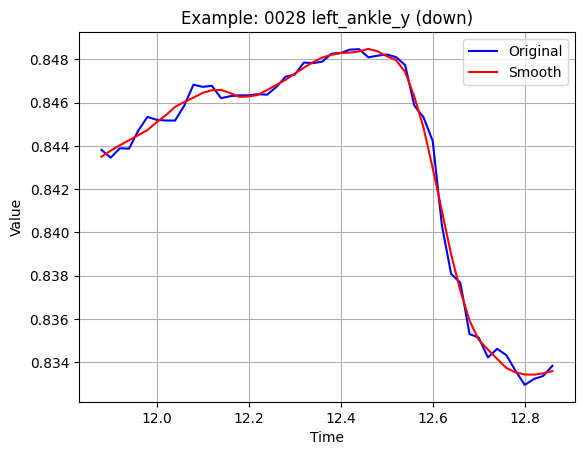

In [3]:
landmark = 'left_ankle_y'
direction = 'down'
video = 'DJI_20250425092743_0028_D'

original_path = DOWN_DIR if direction == 'down' else UP_DIR
original_path = original_path / f'{video}.csv'
smooth_path = Path(str(original_path).replace('combined', 'corrected'))

df = pd.read_csv(original_path)
time     = df['time'].values
original = df[landmark].values
smooth   = pd.read_csv(smooth_path)[landmark].values

plt.plot(time, original, label='Original', color='blue')
plt.plot(time, smooth, label='Smooth', color='red')
plt.grid()
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
vid_id = video.split('_')[2]
plt.title(f'Example: {vid_id} {landmark} ({direction})')
plt.show()


## 2. Hip corrections

Adjust hip keypoints to increase the hip and knee angles during the sitting phases

### 2.1. sit-to-stand

In [4]:
import re

HIP_CORRECTION_CONFIG = {
    '028': {'alpha_left': -0.14, 'alpha_right': -0.08, 'time_offset': 0.15, 'extend_to_end': False, 'monotonic_ramp': True, 'mirror_right': False},
    '030': {'alpha_left': -0.30, 'alpha_right': -0.30, 'time_offset': 0.40, 'extend_to_end': True,  'monotonic_ramp': True,  'mirror_right': False},
    '045': {'alpha_left': -0.0,  'alpha_right': -0.0,  'time_offset': 0,    'extend_to_end': False, 'monotonic_ramp': True, 'mirror_right': False},
    '047': {'alpha_left': -0.30, 'alpha_right': -0.30, 'time_offset': 0.32, 'extend_to_end': False, 'monotonic_ramp': True,  'mirror_right': False},
    '059': {'alpha_left': -0.07, 'alpha_right': -0.0,  'time_offset': 0.10, 'extend_to_end': False, 'monotonic_ramp': True, 'mirror_right': False},
    '061': {'alpha_left': -0.32, 'alpha_right': -0.32, 'time_offset': 0.38, 'extend_to_end': False, 'monotonic_ramp': True , 'mirror_right': True},
    '074': {'alpha_left': -0.35, 'alpha_right': -0.28, 'time_offset': 0.20, 'extend_to_end': False, 'monotonic_ramp': True , 'mirror_right': False},
    '076': {'alpha_left': -0.28, 'alpha_right': -0.28, 'time_offset': 0.35, 'extend_to_end': False, 'monotonic_ramp': True , 'mirror_right': False},
    '091': {'alpha_left': -0.30, 'alpha_right': -0.0,  'time_offset': 0.15, 'extend_to_end': False, 'monotonic_ramp': True , 'mirror_right': False},
    '093': {'alpha_left': -0.32, 'alpha_right': -0.16, 'time_offset': 0.27, 'extend_to_end': False, 'monotonic_ramp': True , 'mirror_right': False},
}


def project_to_length(hip, knee, length):
    vec = hip - knee
    norm = np.linalg.norm(vec)
    if norm < 1e-6:
        return hip
    return knee + vec / norm * length


def correct_hips_alpha(df, mask, alpha_left, alpha_right):
    df = df.copy()
    for i in df.index[mask]:
        LH = np.array([df.at[i, 'left_hip_x'],   df.at[i, 'left_hip_y']])
        RH = np.array([df.at[i, 'right_hip_x'],  df.at[i, 'right_hip_y']])
        LK = np.array([df.at[i, 'left_knee_x'],  df.at[i, 'left_knee_y']])
        RK = np.array([df.at[i, 'right_knee_x'], df.at[i, 'right_knee_y']])

        L_femur = np.linalg.norm(LH - LK)
        R_femur = np.linalg.norm(RH - RK)

        LH_new = LH.copy(); LH_new[1] -= alpha_left  * L_femur
        RH_new = RH.copy(); RH_new[1] -= alpha_right * R_femur

        LH_new = project_to_length(LH_new, LK, L_femur)
        RH_new = project_to_length(RH_new, RK, R_femur)

        df.at[i, 'left_hip_x'],  df.at[i, 'left_hip_y']  = LH_new[0], LH_new[1]
        df.at[i, 'right_hip_x'], df.at[i, 'right_hip_y'] = RH_new[0], RH_new[1]
    return df


def correct_hips_ramp(df, t_const_end, t_ramp_end, alpha_left, alpha_right):
    df = df.copy()
    span = t_ramp_end - t_const_end
    for i in df.index:
        t = df.at[i, 'time']
        if t <= t_const_end:
            al, ar = alpha_left, alpha_right
        else:
            progress = np.clip((t - t_const_end) / span, 0, 1) if span > 0 else 1.0
            s = progress**2 * (3 - 2 * progress)
            al = alpha_left  * (1 - s)
            ar = alpha_right * (1 - s)

        LH = np.array([df.at[i, 'left_hip_x'],   df.at[i, 'left_hip_y']])
        RH = np.array([df.at[i, 'right_hip_x'],  df.at[i, 'right_hip_y']])
        LK = np.array([df.at[i, 'left_knee_x'],  df.at[i, 'left_knee_y']])
        RK = np.array([df.at[i, 'right_knee_x'], df.at[i, 'right_knee_y']])

        L_femur = np.linalg.norm(LH - LK)
        R_femur = np.linalg.norm(RH - RK)

        LH_new = LH.copy(); LH_new[1] -= al * L_femur
        RH_new = RH.copy(); RH_new[1] -= ar * R_femur

        LH_new = project_to_length(LH_new, LK, L_femur)
        RH_new = project_to_length(RH_new, RK, R_femur)

        df.at[i, 'left_hip_x'],  df.at[i, 'left_hip_y']  = LH_new[0], LH_new[1]
        df.at[i, 'right_hip_x'], df.at[i, 'right_hip_y'] = RH_new[0], RH_new[1]
    return df


def mirror_left_to_right(df):
    df = df.copy()
    df['left_hip_y']  = df['right_hip_y']
    df['left_knee_y'] = df['right_knee_y']
    for i in df.index:
        LH = np.array([df.at[i, 'left_hip_x'],  df.at[i, 'left_hip_y']])
        LK = np.array([df.at[i, 'left_knee_x'], df.at[i, 'left_knee_y']])
        L_femur = np.linalg.norm(
            np.array([df.at[i, 'right_hip_x'],  df.at[i, 'right_hip_y']]) -
            np.array([df.at[i, 'right_knee_x'], df.at[i, 'right_knee_y']])
        )
        LH_proj = project_to_length(LH, LK, L_femur)
        df.at[i, 'left_hip_x'] = LH_proj[0]
        df.at[i, 'left_hip_y'] = LH_proj[1]
    return df


def get_sitting_mask(df, vid, time_offset=0):
    return df['time'] <= UP_TIME_DICT[vid][4] + time_offset


for stem, vdict in sagvoy_dict['up'].items():
    match = re.search(r'_0(\d{3})_D', stem)
    if not match:
        continue
    vid = match.group(1)
    if vid not in HIP_CORRECTION_CONFIG:
        continue

    cfg = HIP_CORRECTION_CONFIG[vid]
    df  = vdict['df'].copy()

    if cfg['monotonic_ramp']:
        df = correct_hips_ramp(df, UP_TIME_DICT[vid][4], UP_TIME_DICT[vid][5], cfg['alpha_left'], cfg['alpha_right'])
    elif cfg['extend_to_end']:
        df = correct_hips_alpha(df, np.ones(len(df), dtype=bool), cfg['alpha_left'], cfg['alpha_right'])
    else:
        mask = get_sitting_mask(df, vid, cfg['time_offset'])
        df = correct_hips_alpha(df, mask, cfg['alpha_left'], cfg['alpha_right'])

    if cfg['mirror_right']:
        df = mirror_left_to_right(df)

    df.to_csv(vdict['out_path'], index=False)
    print(f"up {vid}: alpha_left={cfg['alpha_left']}, alpha_right={cfg['alpha_right']}, time_offset={cfg['time_offset']}, extend_to_end={cfg['extend_to_end']}, monotonic_ramp={cfg['monotonic_ramp']}, mirror_right={cfg['mirror_right']}")


up 030: alpha_left=-0.3, alpha_right=-0.3, time_offset=0.4, extend_to_end=True, monotonic_ramp=True, mirror_right=False
up 061: alpha_left=-0.32, alpha_right=-0.32, time_offset=0.38, extend_to_end=False, monotonic_ramp=True, mirror_right=True
up 076: alpha_left=-0.28, alpha_right=-0.28, time_offset=0.35, extend_to_end=False, monotonic_ramp=True, mirror_right=False
up 045: alpha_left=-0.0, alpha_right=-0.0, time_offset=0, extend_to_end=False, monotonic_ramp=True, mirror_right=False
up 091: alpha_left=-0.3, alpha_right=-0.0, time_offset=0.15, extend_to_end=False, monotonic_ramp=True, mirror_right=False
up 093: alpha_left=-0.32, alpha_right=-0.16, time_offset=0.27, extend_to_end=False, monotonic_ramp=True, mirror_right=False
up 074: alpha_left=-0.35, alpha_right=-0.28, time_offset=0.2, extend_to_end=False, monotonic_ramp=True, mirror_right=False
up 028: alpha_left=-0.14, alpha_right=-0.08, time_offset=0.15, extend_to_end=False, monotonic_ramp=True, mirror_right=False
up 047: alpha_left=-0

### 2.2. stand-to-sit

In [5]:
HIP_CORRECTION_CONFIG_DOWN = {
    '028': {'alpha_left': -0.20, 'alpha_right': -0.00, 'time_offset': 0.35},
    '030': {'alpha_left': -0.35, 'alpha_right': -0.35, 'time_offset': 0.60},
    '045': {'alpha_left': -0.18, 'alpha_right': -0.10, 'time_offset': 0.35},
    '047': {'alpha_left': -0.36, 'alpha_right': -0.36, 'time_offset': 0.55},
    '059': {'alpha_left': -0.10, 'alpha_right':  0,    'time_offset': 0.50},
    '061': {'alpha_left': -0.25, 'alpha_right': -0.15, 'time_offset': 0.64},
    '074': {'alpha_left': -0.35, 'alpha_right': -0.35, 'time_offset': 0.28},
    '076': {'alpha_left': -0.35, 'alpha_right': -0.35, 'time_offset': 0.40},
    '091': {'alpha_left': -0.31, 'alpha_right': -0.11, 'time_offset': 0.18},
    '093': {'alpha_left': -0.37, 'alpha_right': -0.18, 'time_offset': 0.50},
}


def correct_hips_smooth_down(df, t_start, t_end_ramp, dmax_left, dmax_right):
    df = df.copy()
    span = t_end_ramp - t_start
    for i in df.index:
        t = df.at[i, 'time']
        if t < t_start:
            continue
        progress = np.clip((t - t_start) / span, 0, 1) if span > 0 else 1.0
        s = progress**2 * (3 - 2 * progress)

        LH = np.array([df.at[i, 'left_hip_x'],   df.at[i, 'left_hip_y']])
        RH = np.array([df.at[i, 'right_hip_x'],  df.at[i, 'right_hip_y']])
        LK = np.array([df.at[i, 'left_knee_x'],  df.at[i, 'left_knee_y']])
        RK = np.array([df.at[i, 'right_knee_x'], df.at[i, 'right_knee_y']])

        L_femur = np.linalg.norm(LH - LK)
        R_femur = np.linalg.norm(RH - RK)

        LH_new = LH.copy(); LH_new[1] -= dmax_left  * s * L_femur
        RH_new = RH.copy(); RH_new[1] -= dmax_right * s * R_femur

        LH_new = project_to_length(LH_new, LK, L_femur)
        RH_new = project_to_length(RH_new, RK, R_femur)

        df.at[i, 'left_hip_x'],  df.at[i, 'left_hip_y']  = LH_new[0], LH_new[1]
        df.at[i, 'right_hip_x'], df.at[i, 'right_hip_y'] = RH_new[0], RH_new[1]
    return df


for stem, vdict in sagvoy_dict['down'].items():
    match = re.search(r'_0(\d{3})_D', stem)
    if not match:
        continue
    vid = match.group(1)
    if vid not in HIP_CORRECTION_CONFIG_DOWN:
        continue

    cfg = HIP_CORRECTION_CONFIG_DOWN[vid]
    df  = vdict['df'].copy()

    t_start = DOWN_TIME_DICT[vid][1]
    t_end_ramp = DOWN_TIME_DICT[vid][3]
    df = correct_hips_smooth_down(df, t_start, t_end_ramp, cfg['alpha_left'], cfg['alpha_right'])

    df.to_csv(vdict['out_path'], index=False)
    print(f"down {vid}: alpha_left={cfg['alpha_left']}, alpha_right={cfg['alpha_right']}, t_start={t_start:.2f}, t_end_ramp={t_end_ramp:.2f}")


down 030: alpha_left=-0.35, alpha_right=-0.35, t_start=9.70, t_end_ramp=10.64
down 061: alpha_left=-0.25, alpha_right=-0.15, t_start=10.88, t_end_ramp=12.26
down 076: alpha_left=-0.35, alpha_right=-0.35, t_start=8.72, t_end_ramp=9.73
down 045: alpha_left=-0.18, alpha_right=-0.1, t_start=7.96, t_end_ramp=8.74
down 091: alpha_left=-0.31, alpha_right=-0.11, t_start=7.58, t_end_ramp=8.09
down 093: alpha_left=-0.37, alpha_right=-0.18, t_start=9.24, t_end_ramp=10.08
down 074: alpha_left=-0.35, alpha_right=-0.35, t_start=7.30, t_end_ramp=7.88
down 028: alpha_left=-0.2, alpha_right=-0.0, t_start=11.90, t_end_ramp=12.57
down 047: alpha_left=-0.36, alpha_right=-0.36, t_start=10.14, t_end_ramp=11.10
down 059: alpha_left=-0.1, alpha_right=0, t_start=9.18, t_end_ramp=10.37


## Angle plots

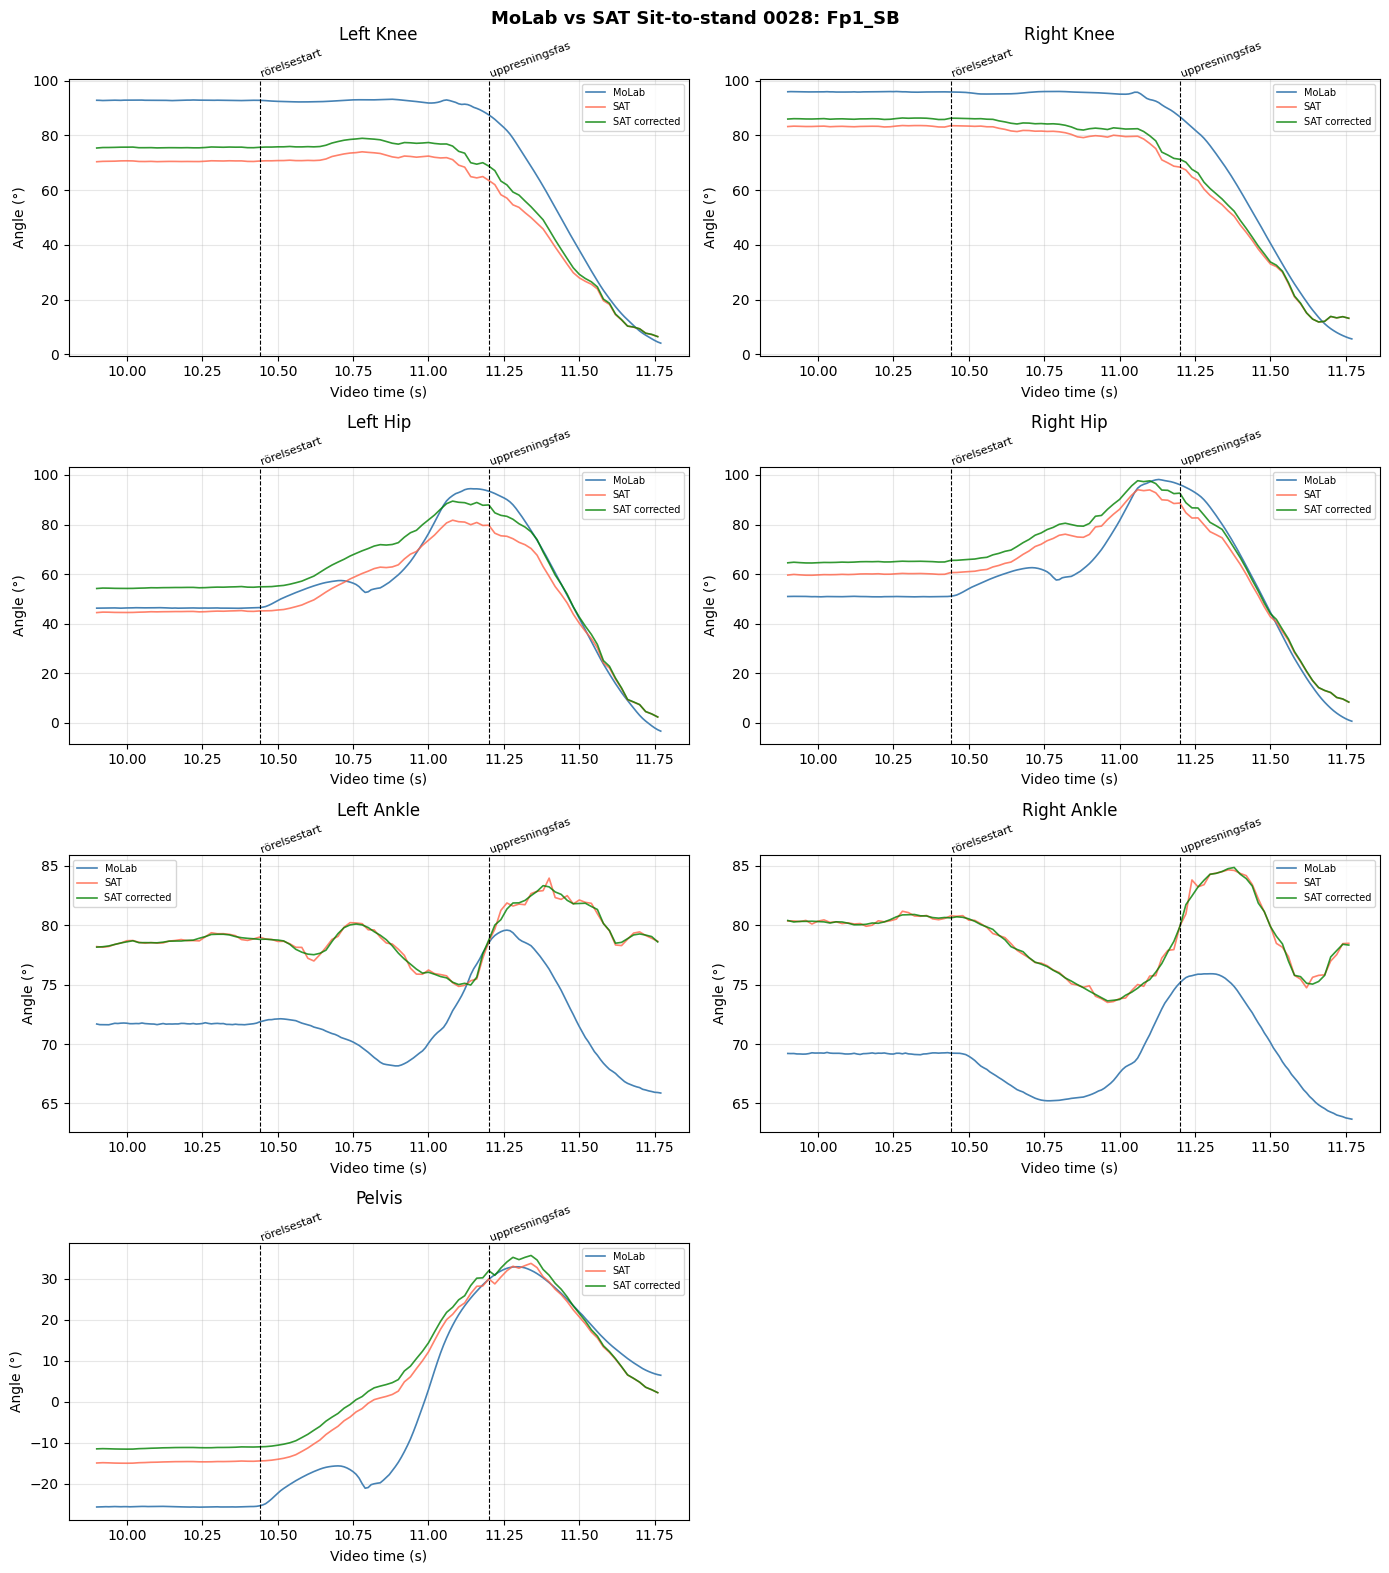

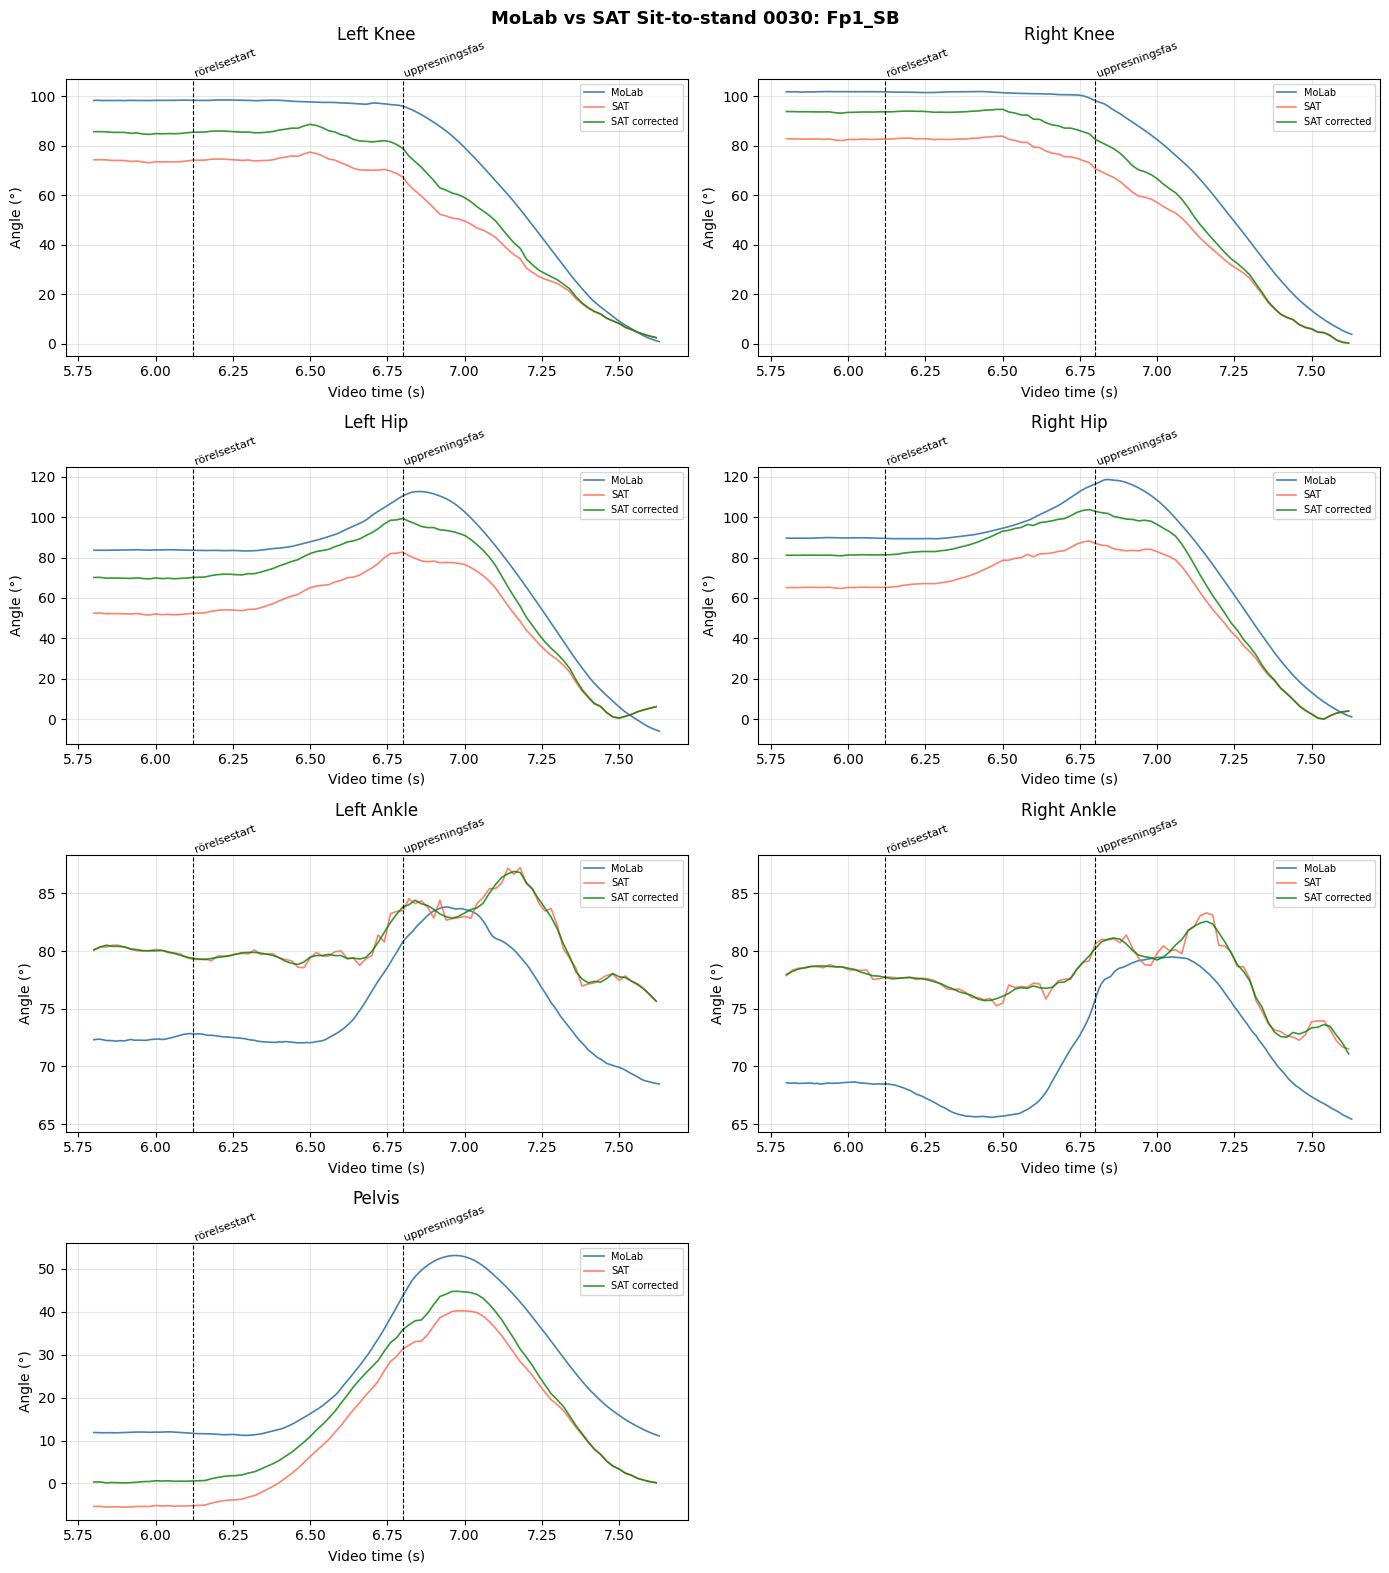

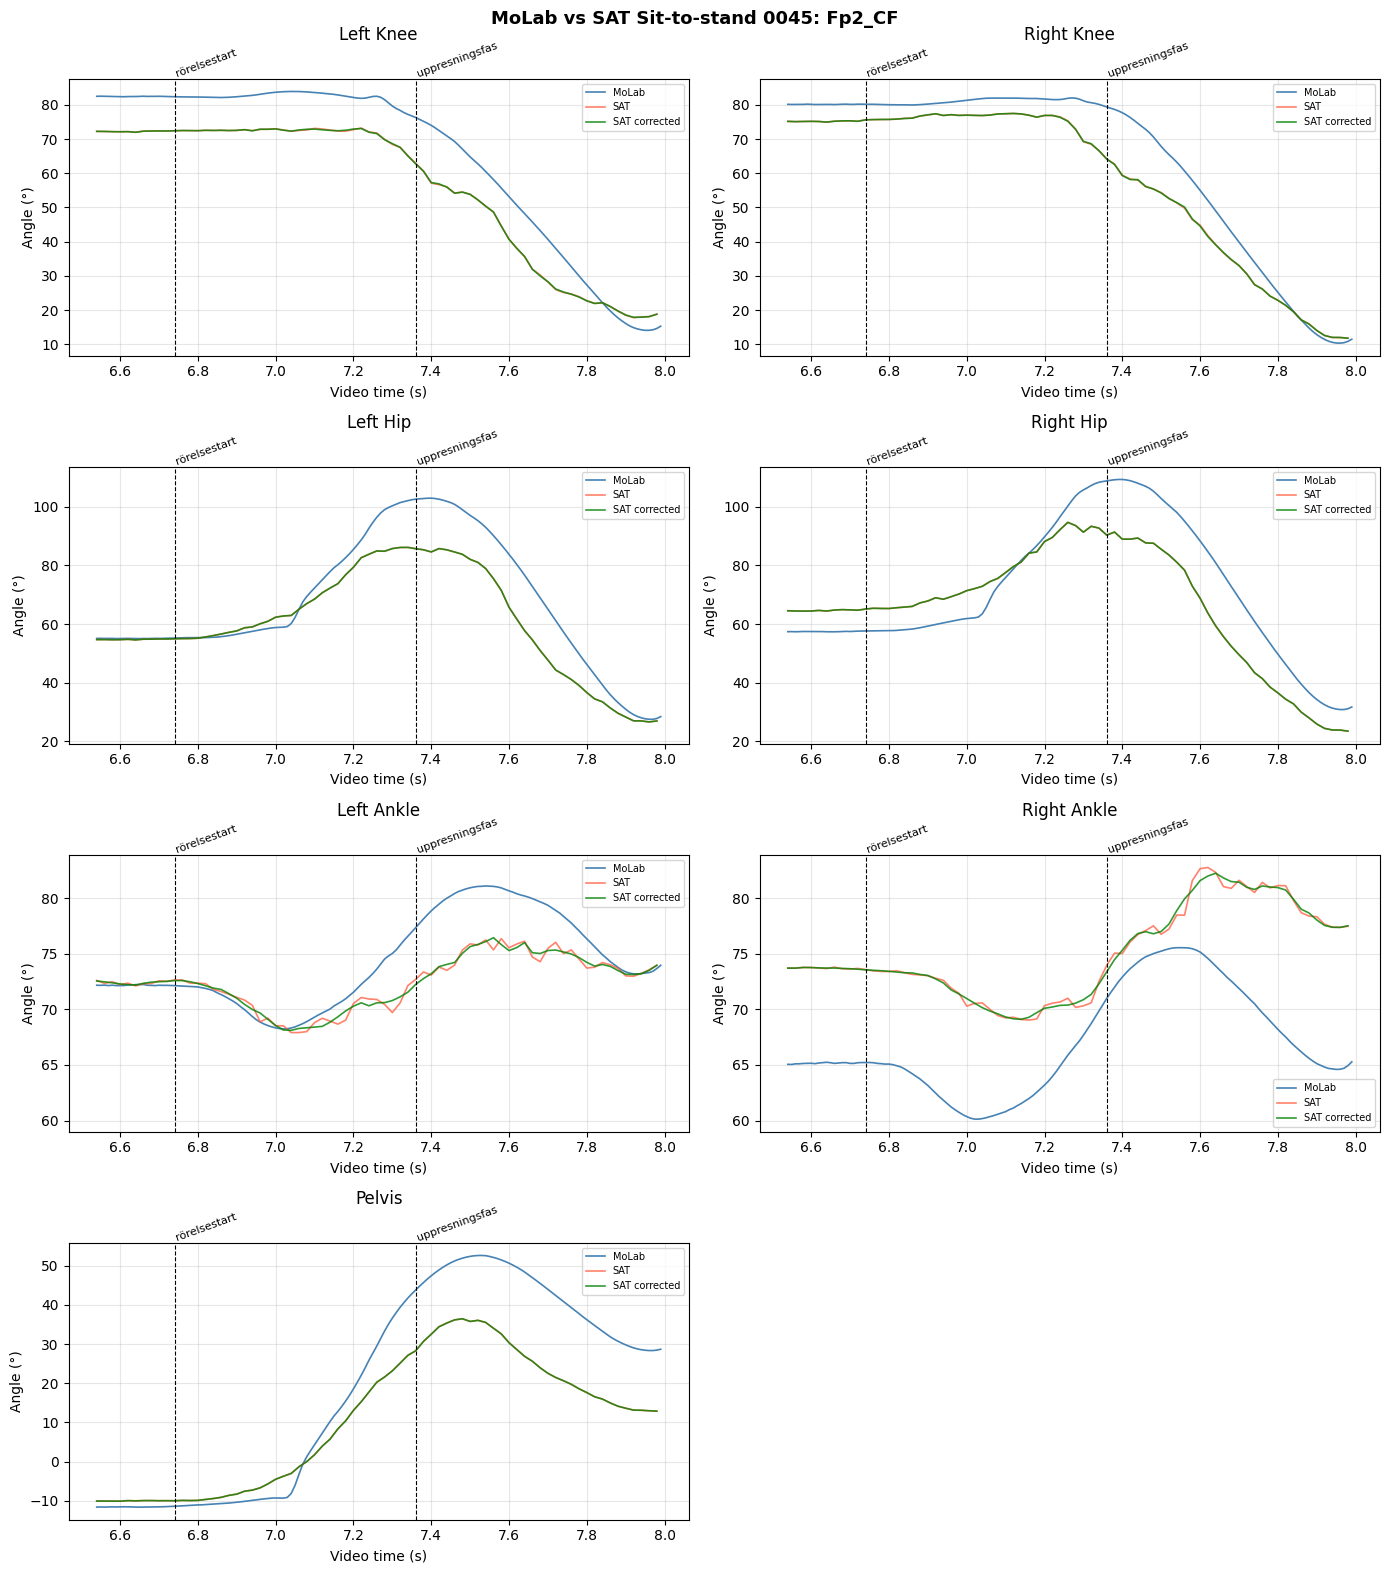

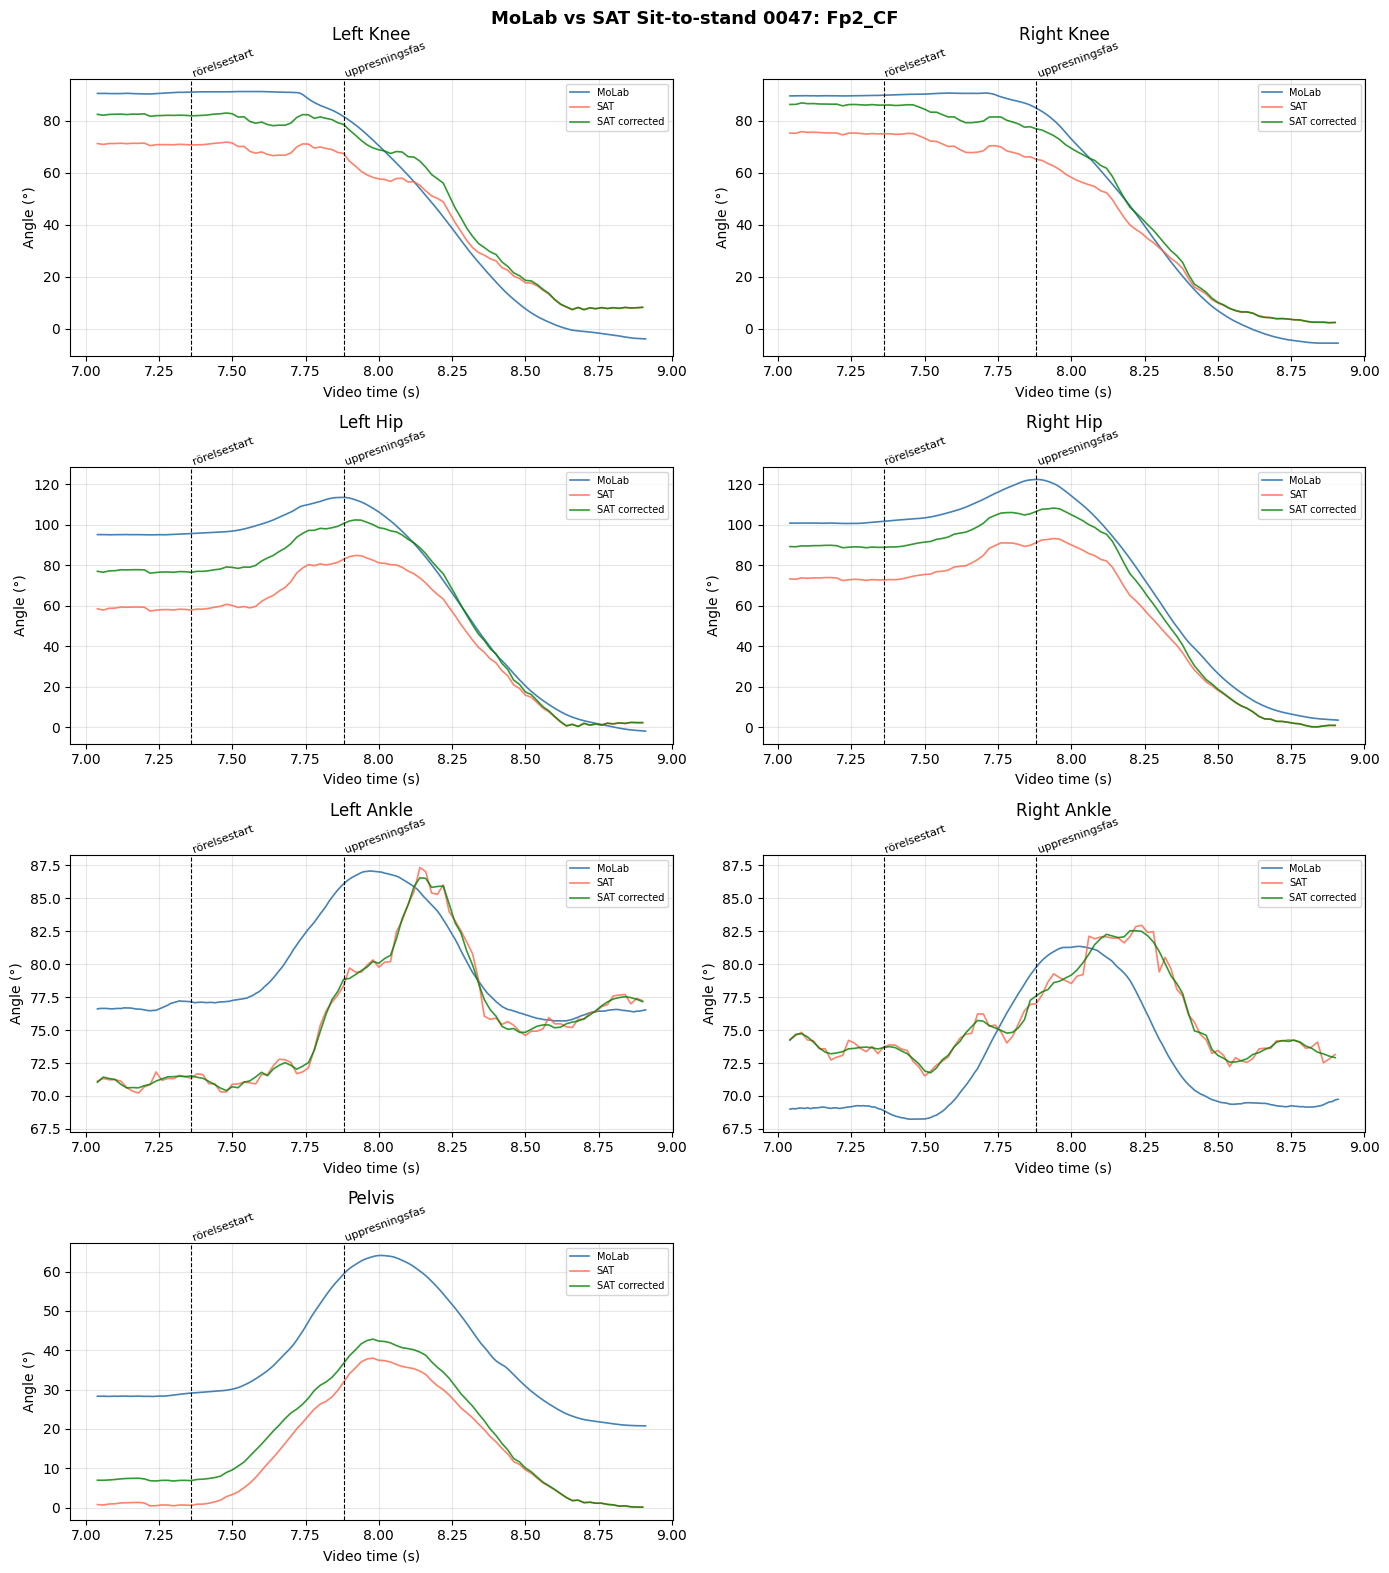

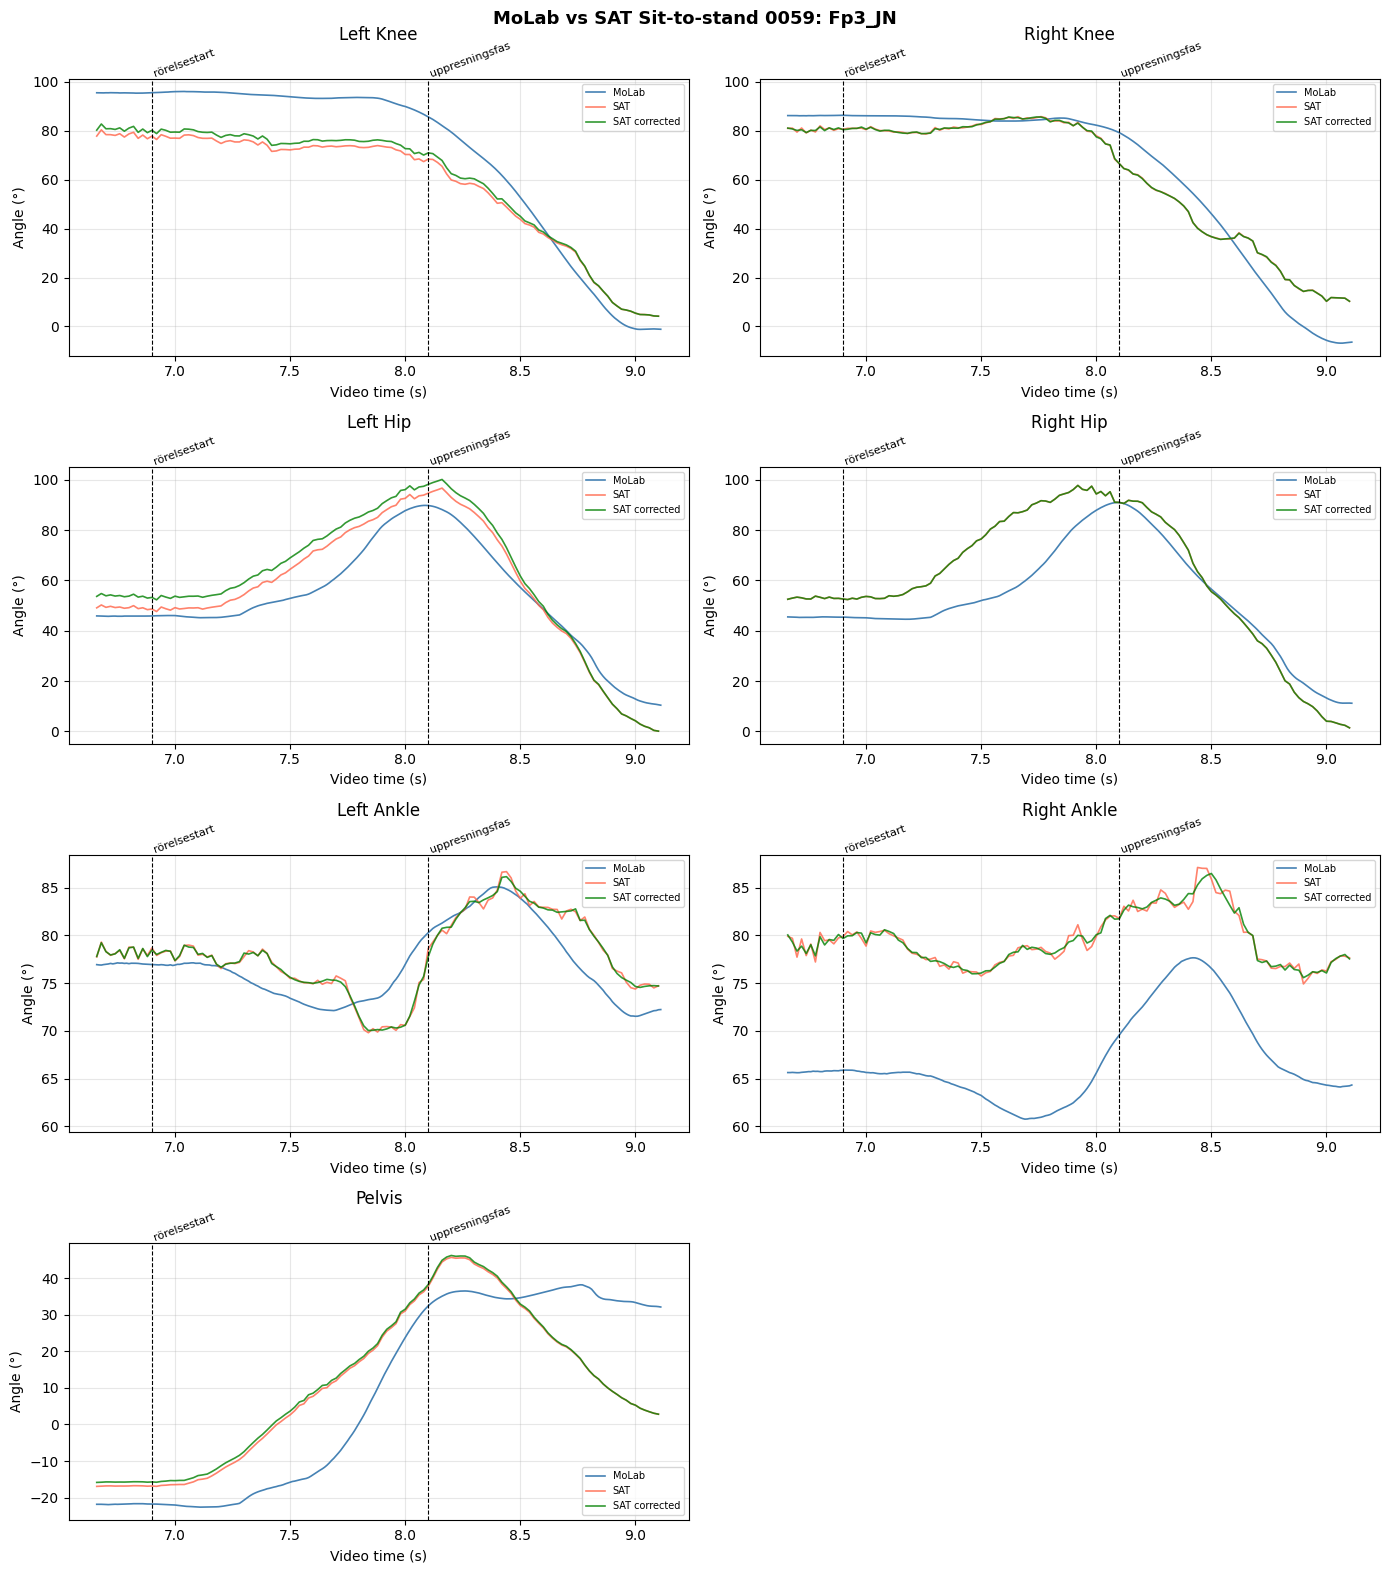

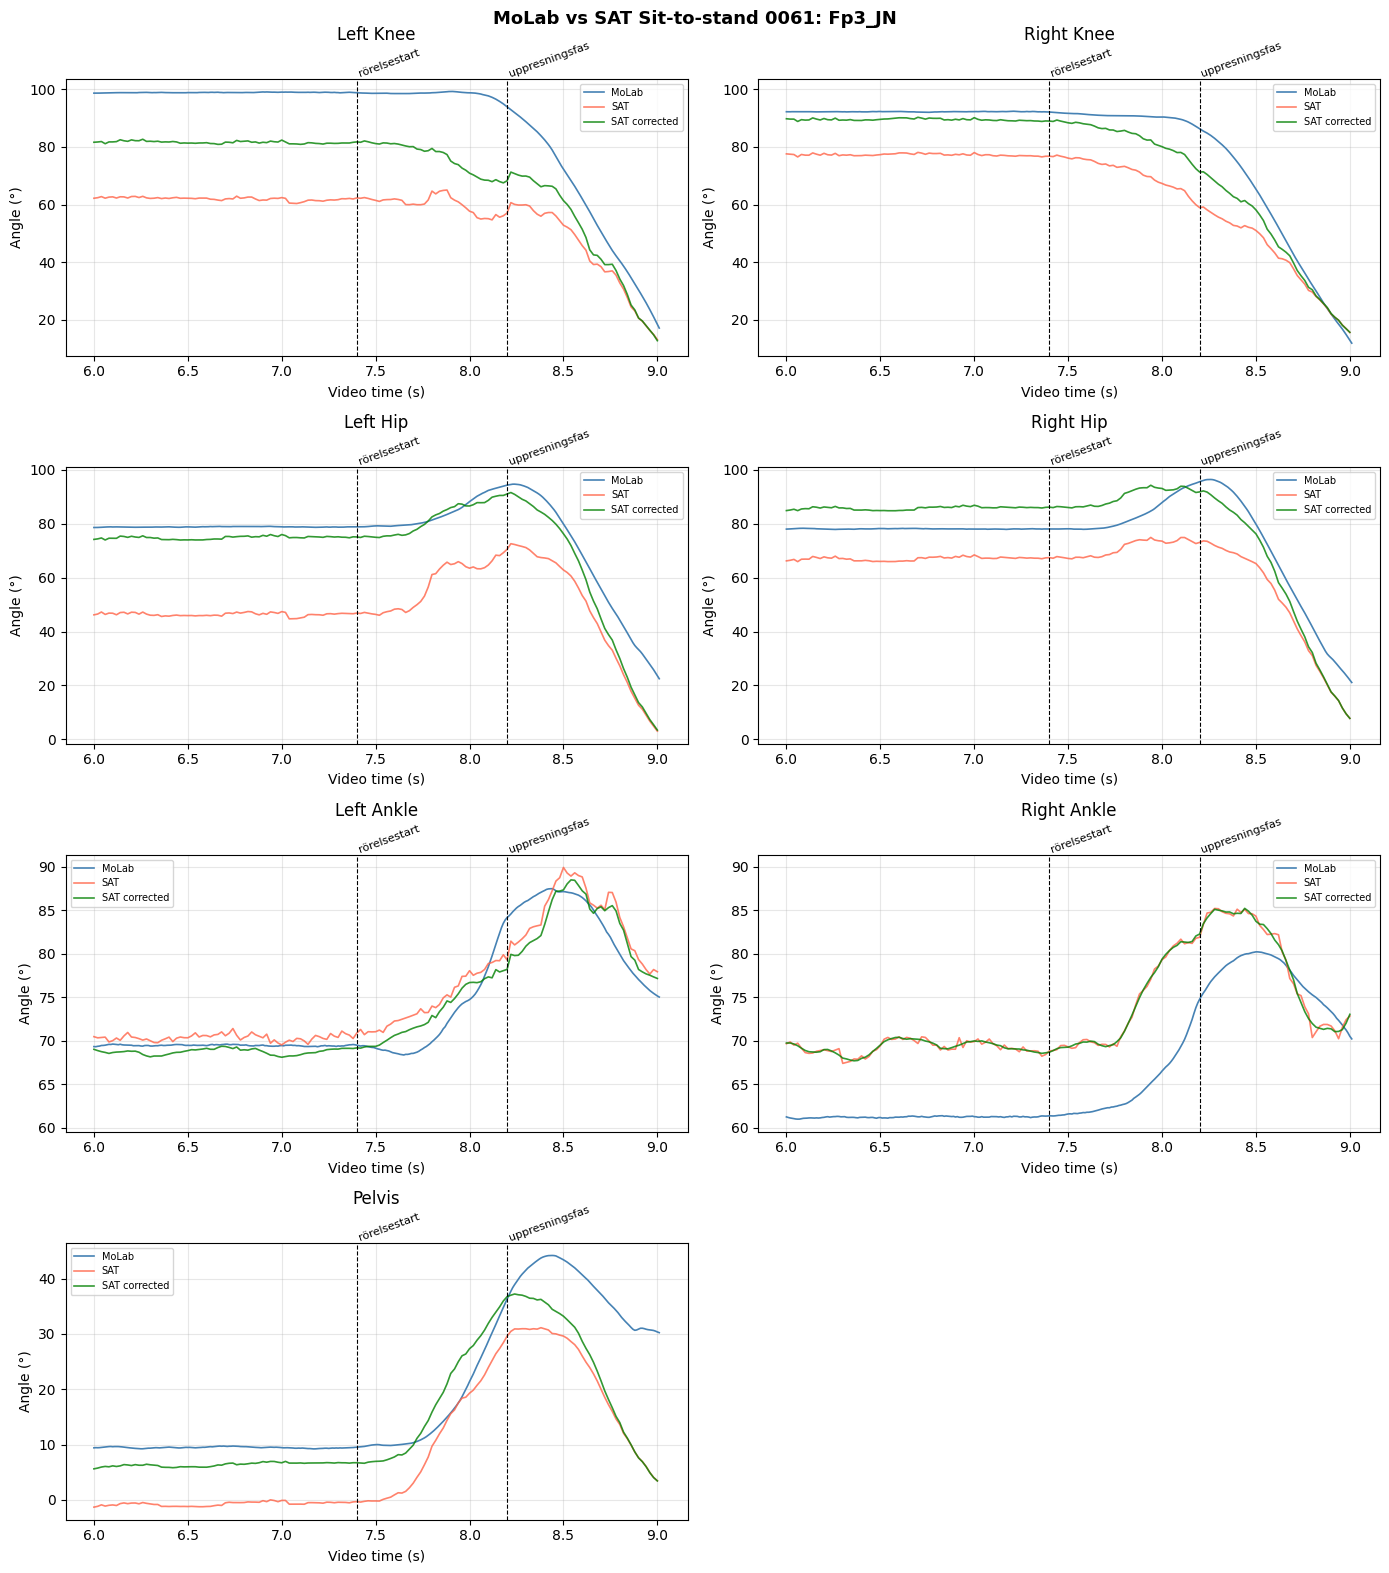

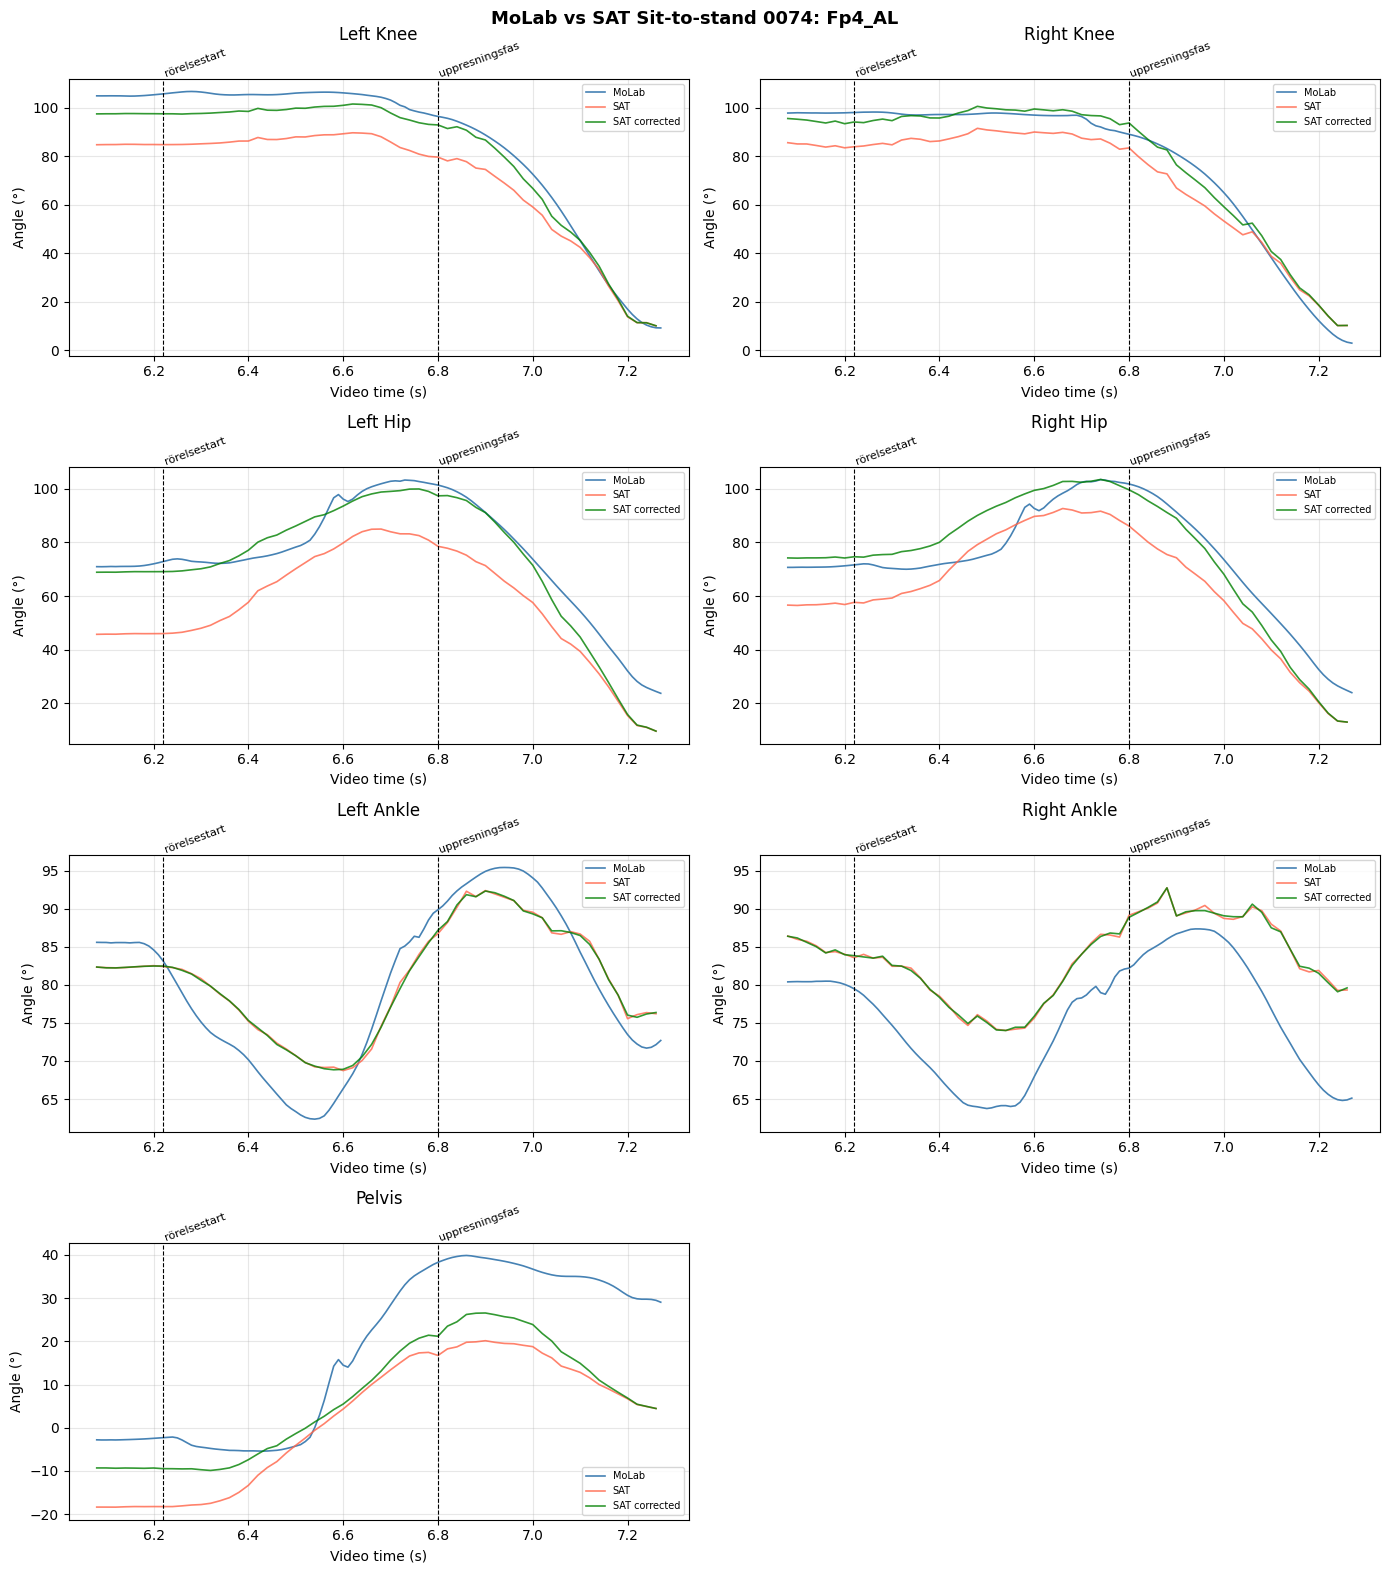

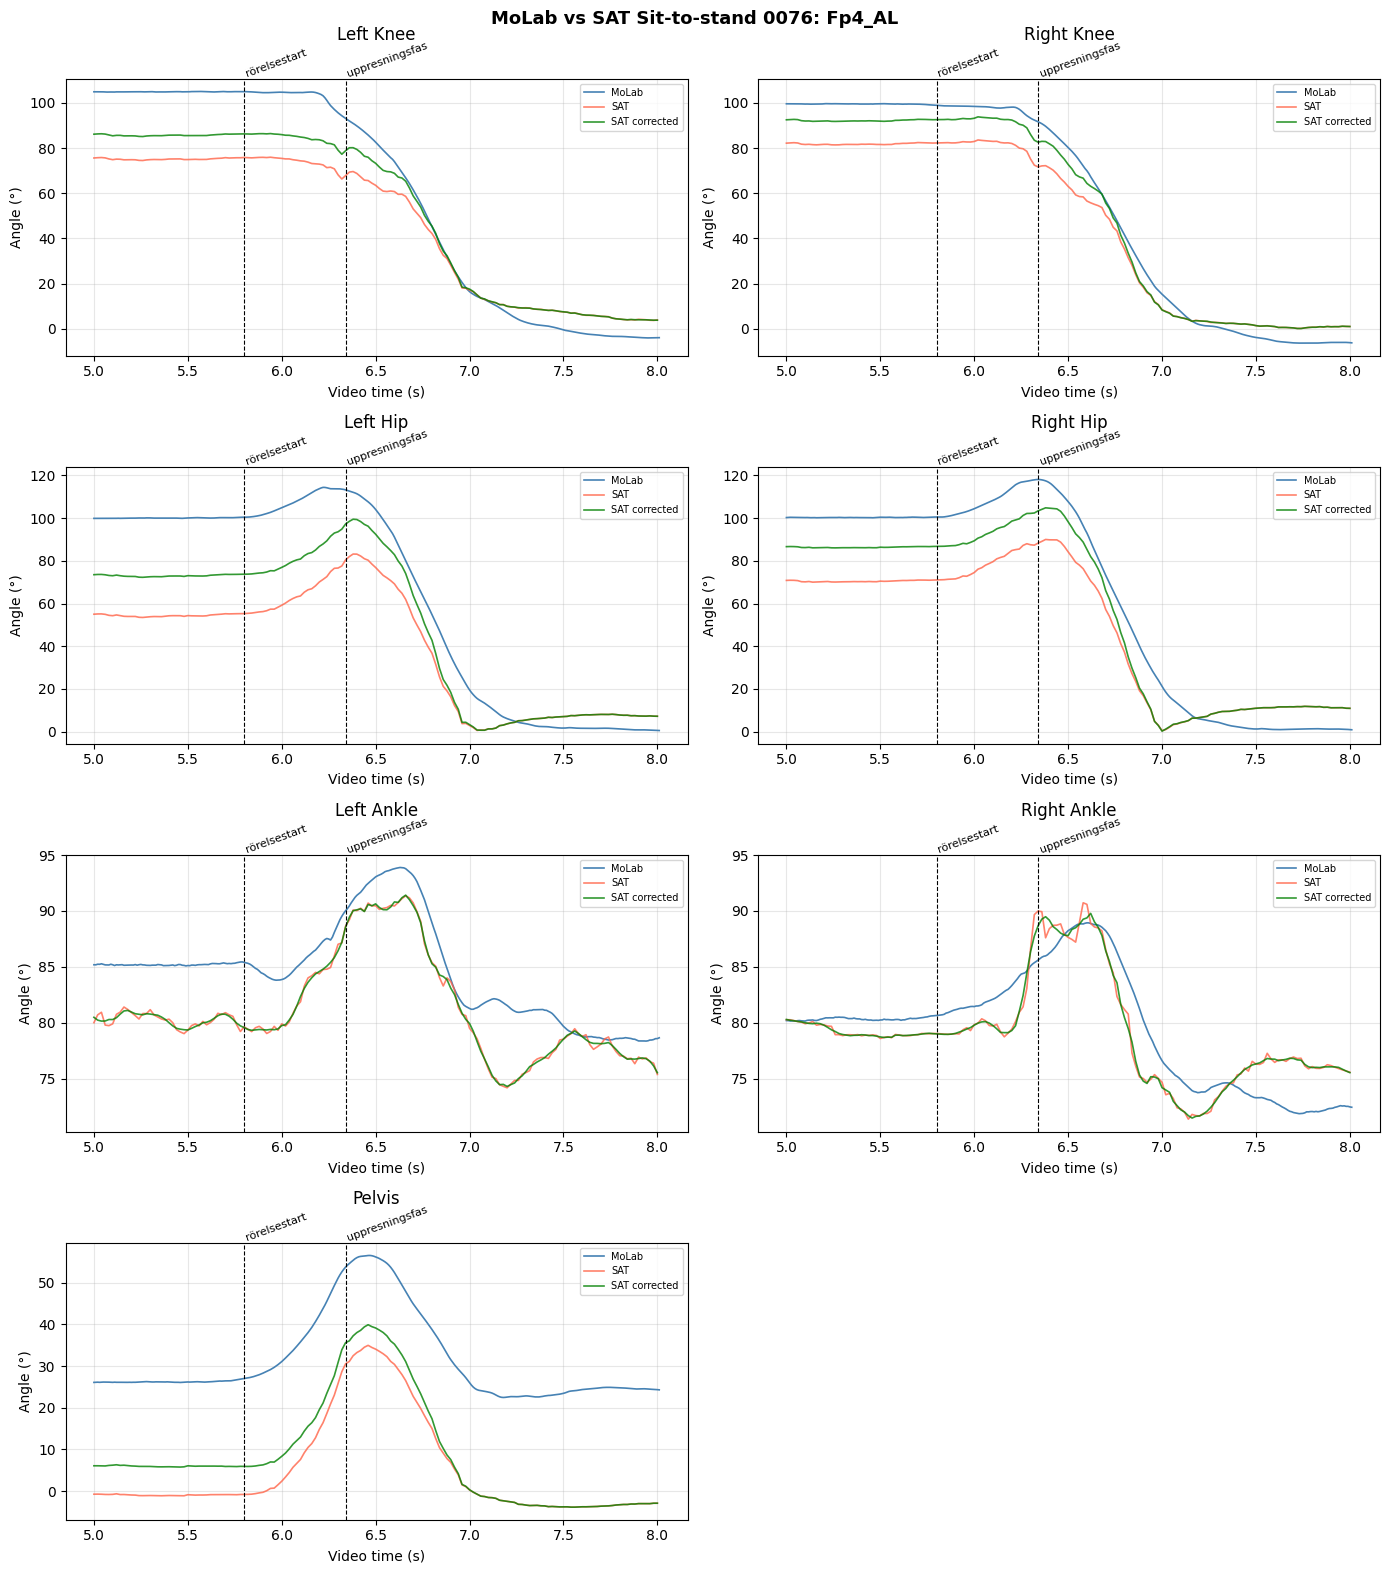

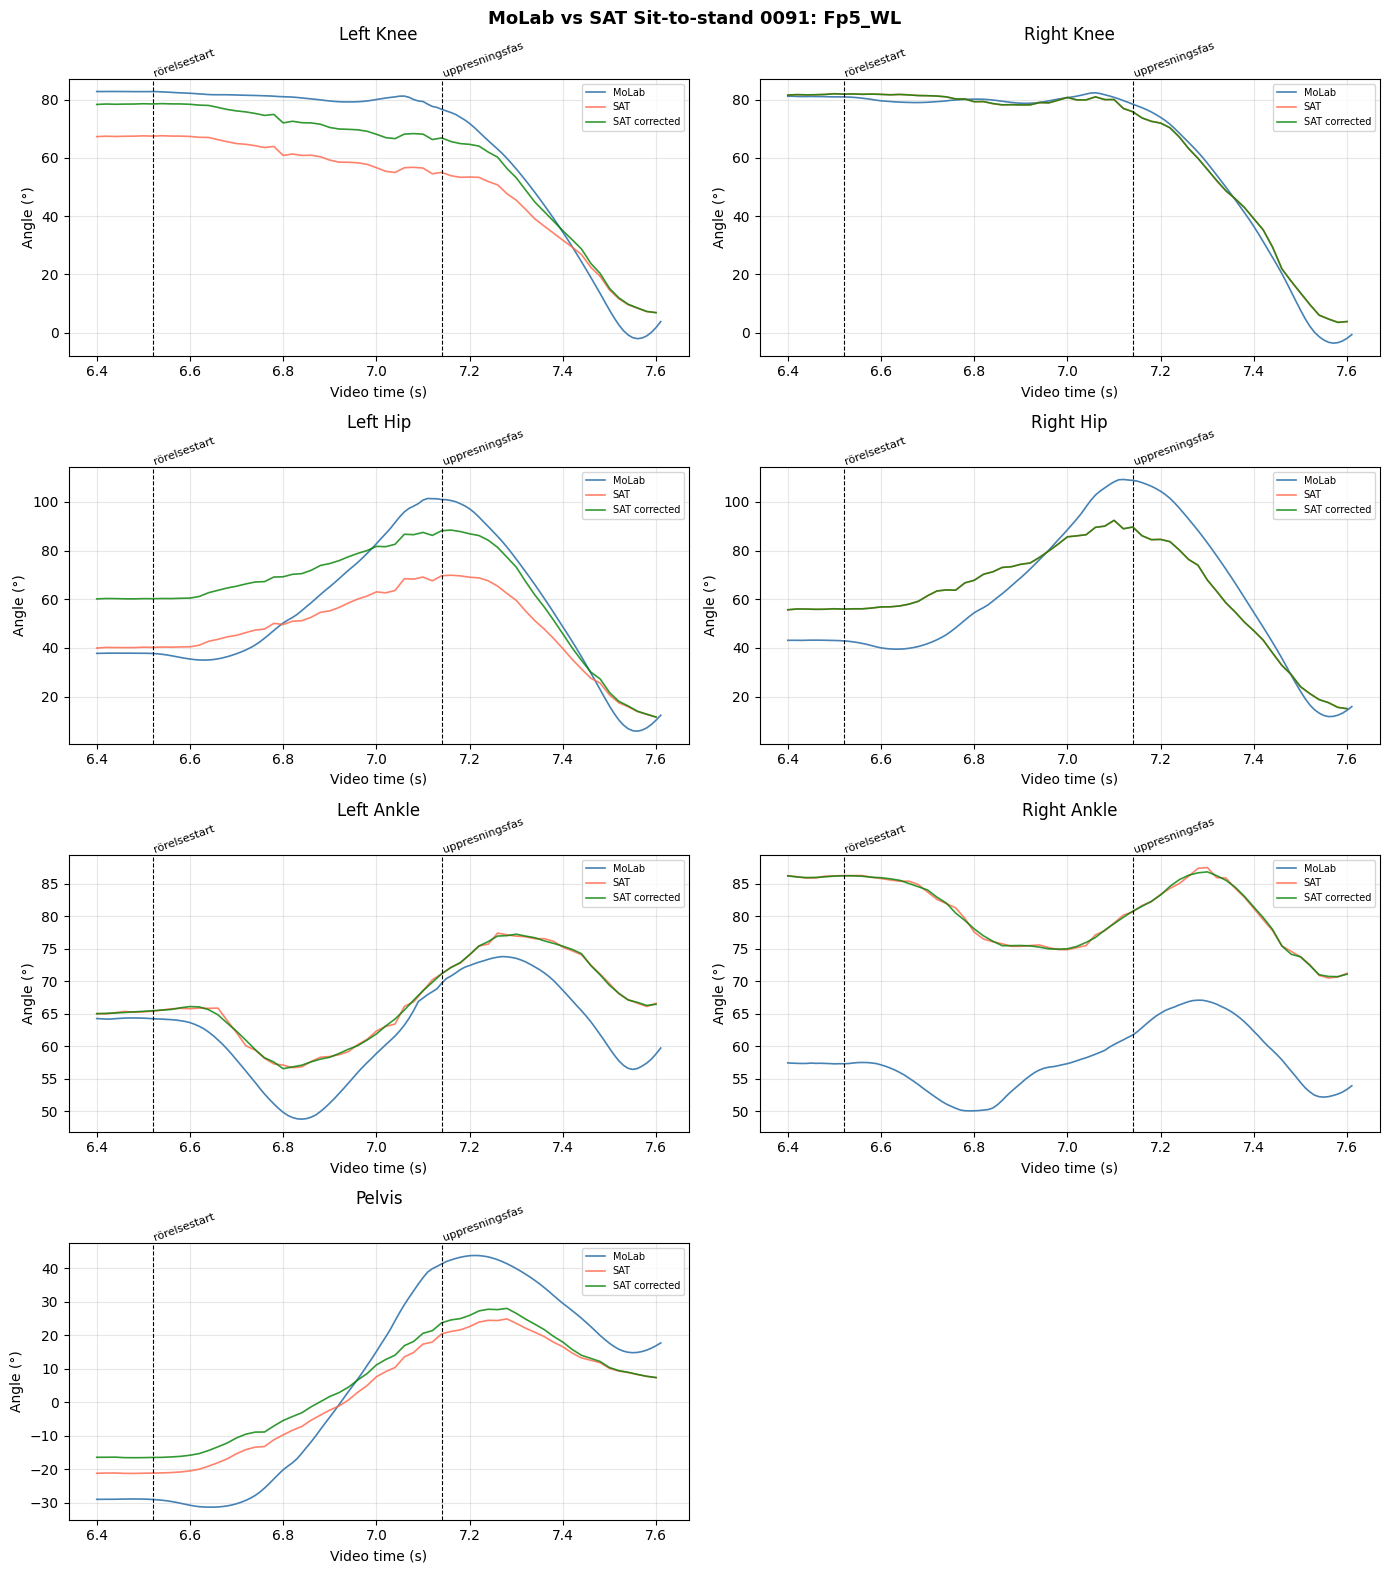

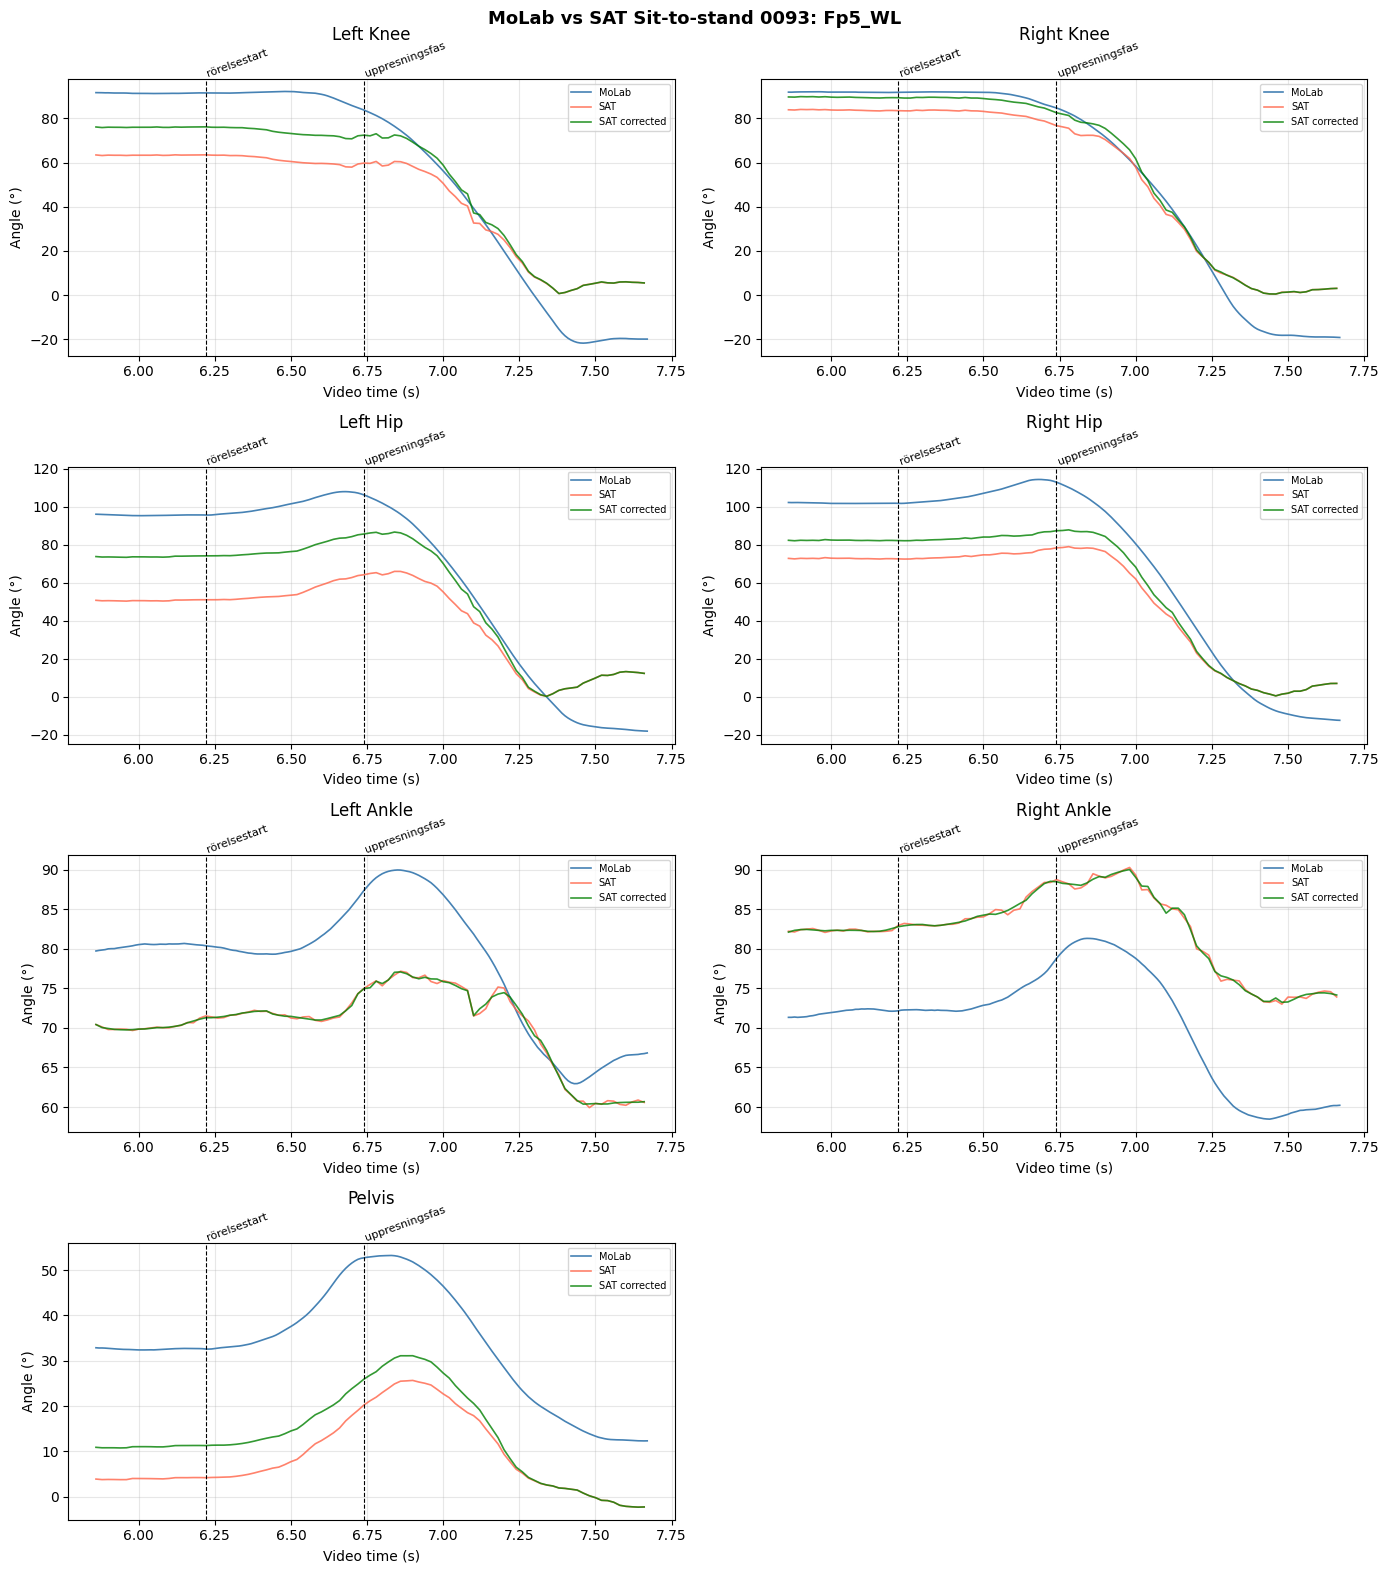

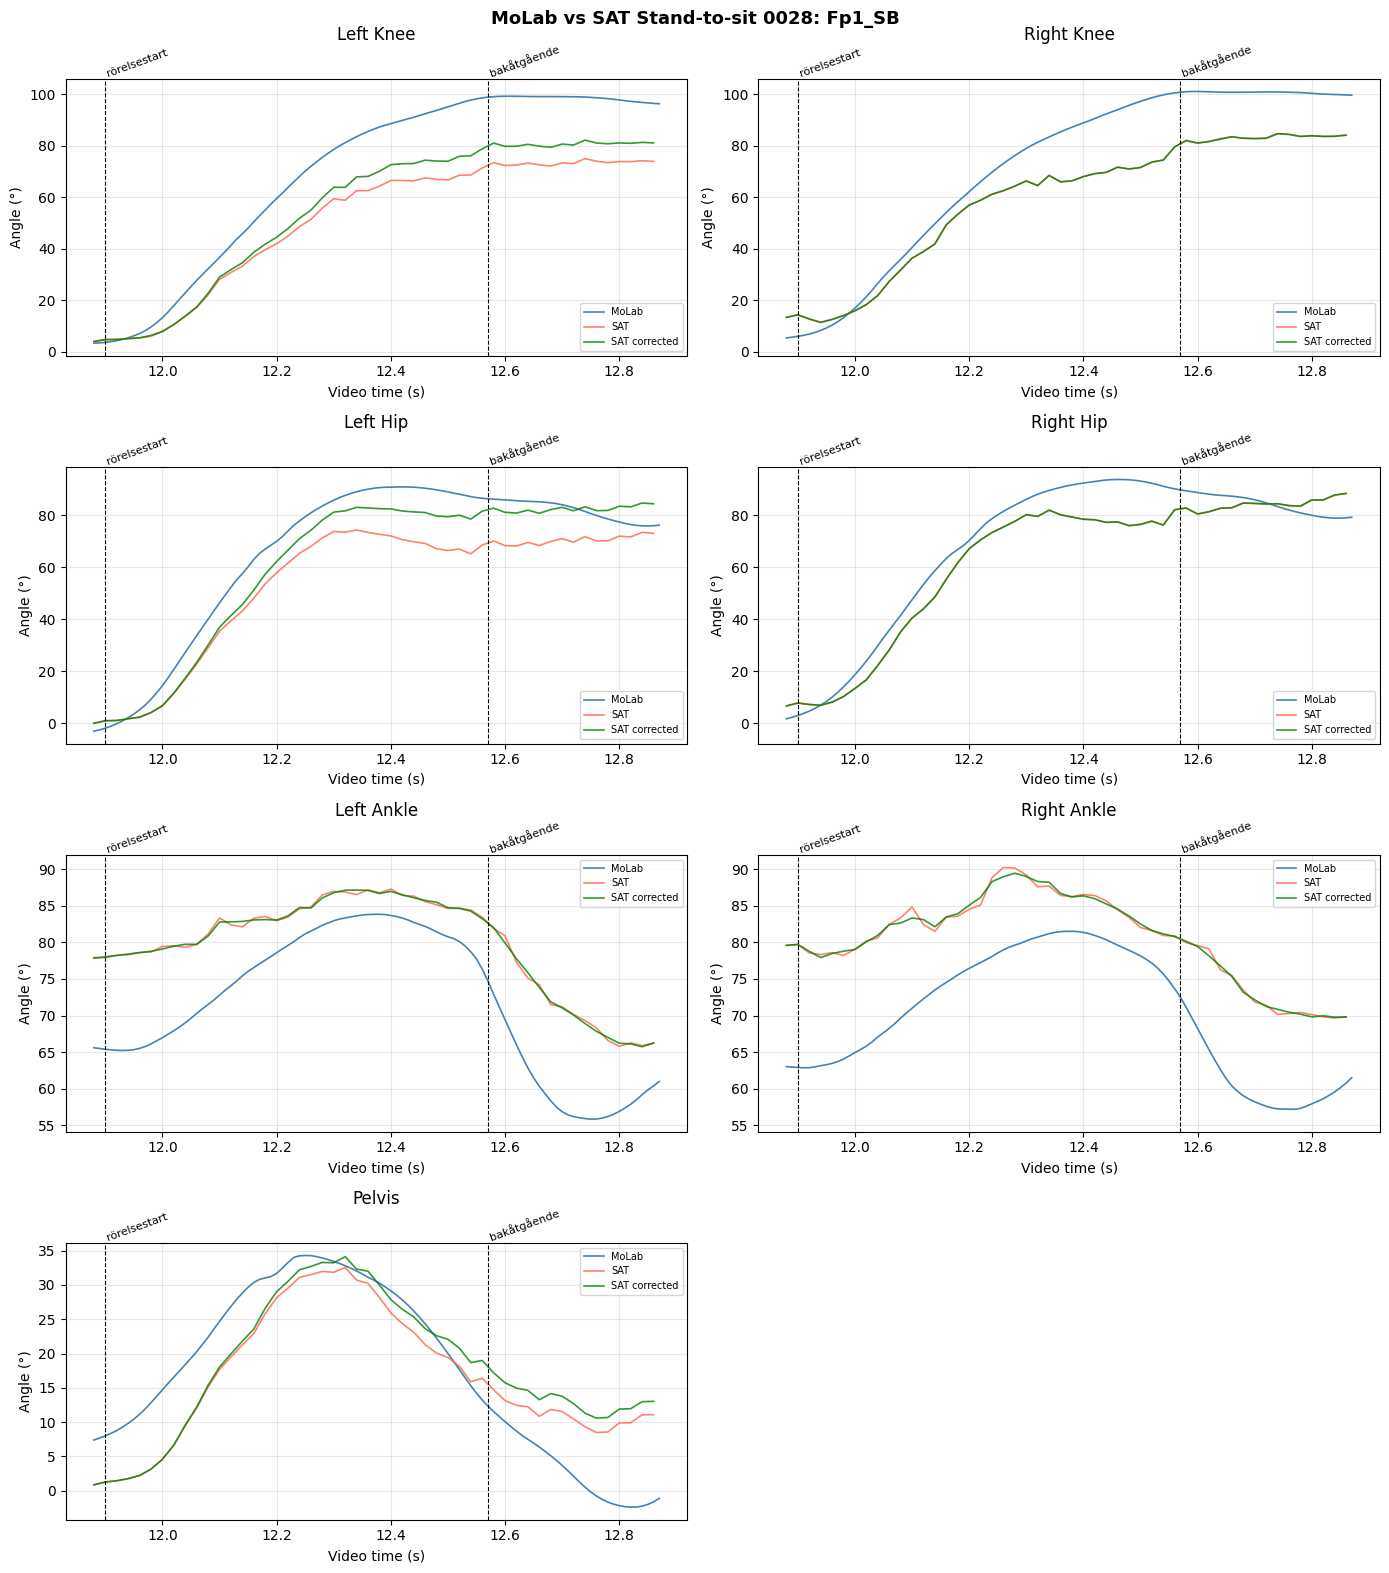

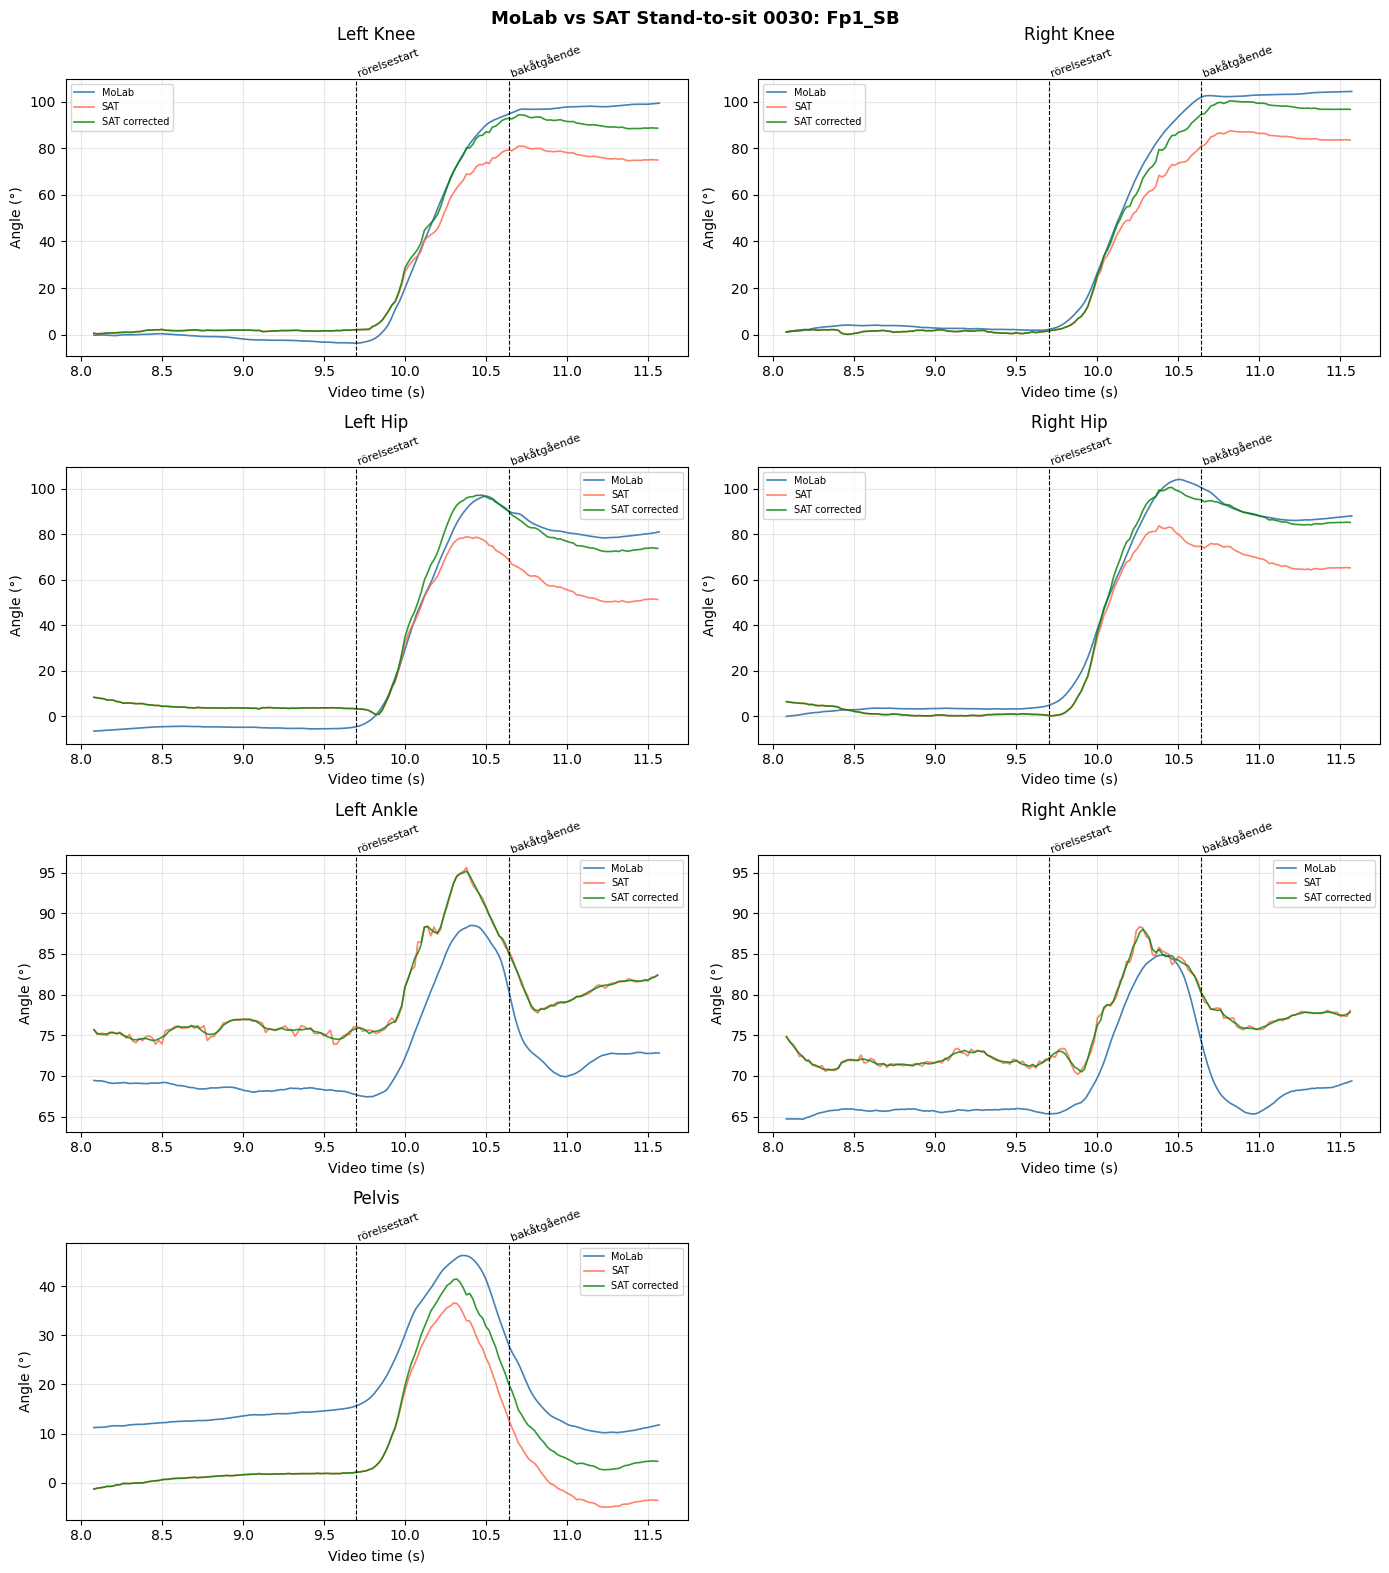

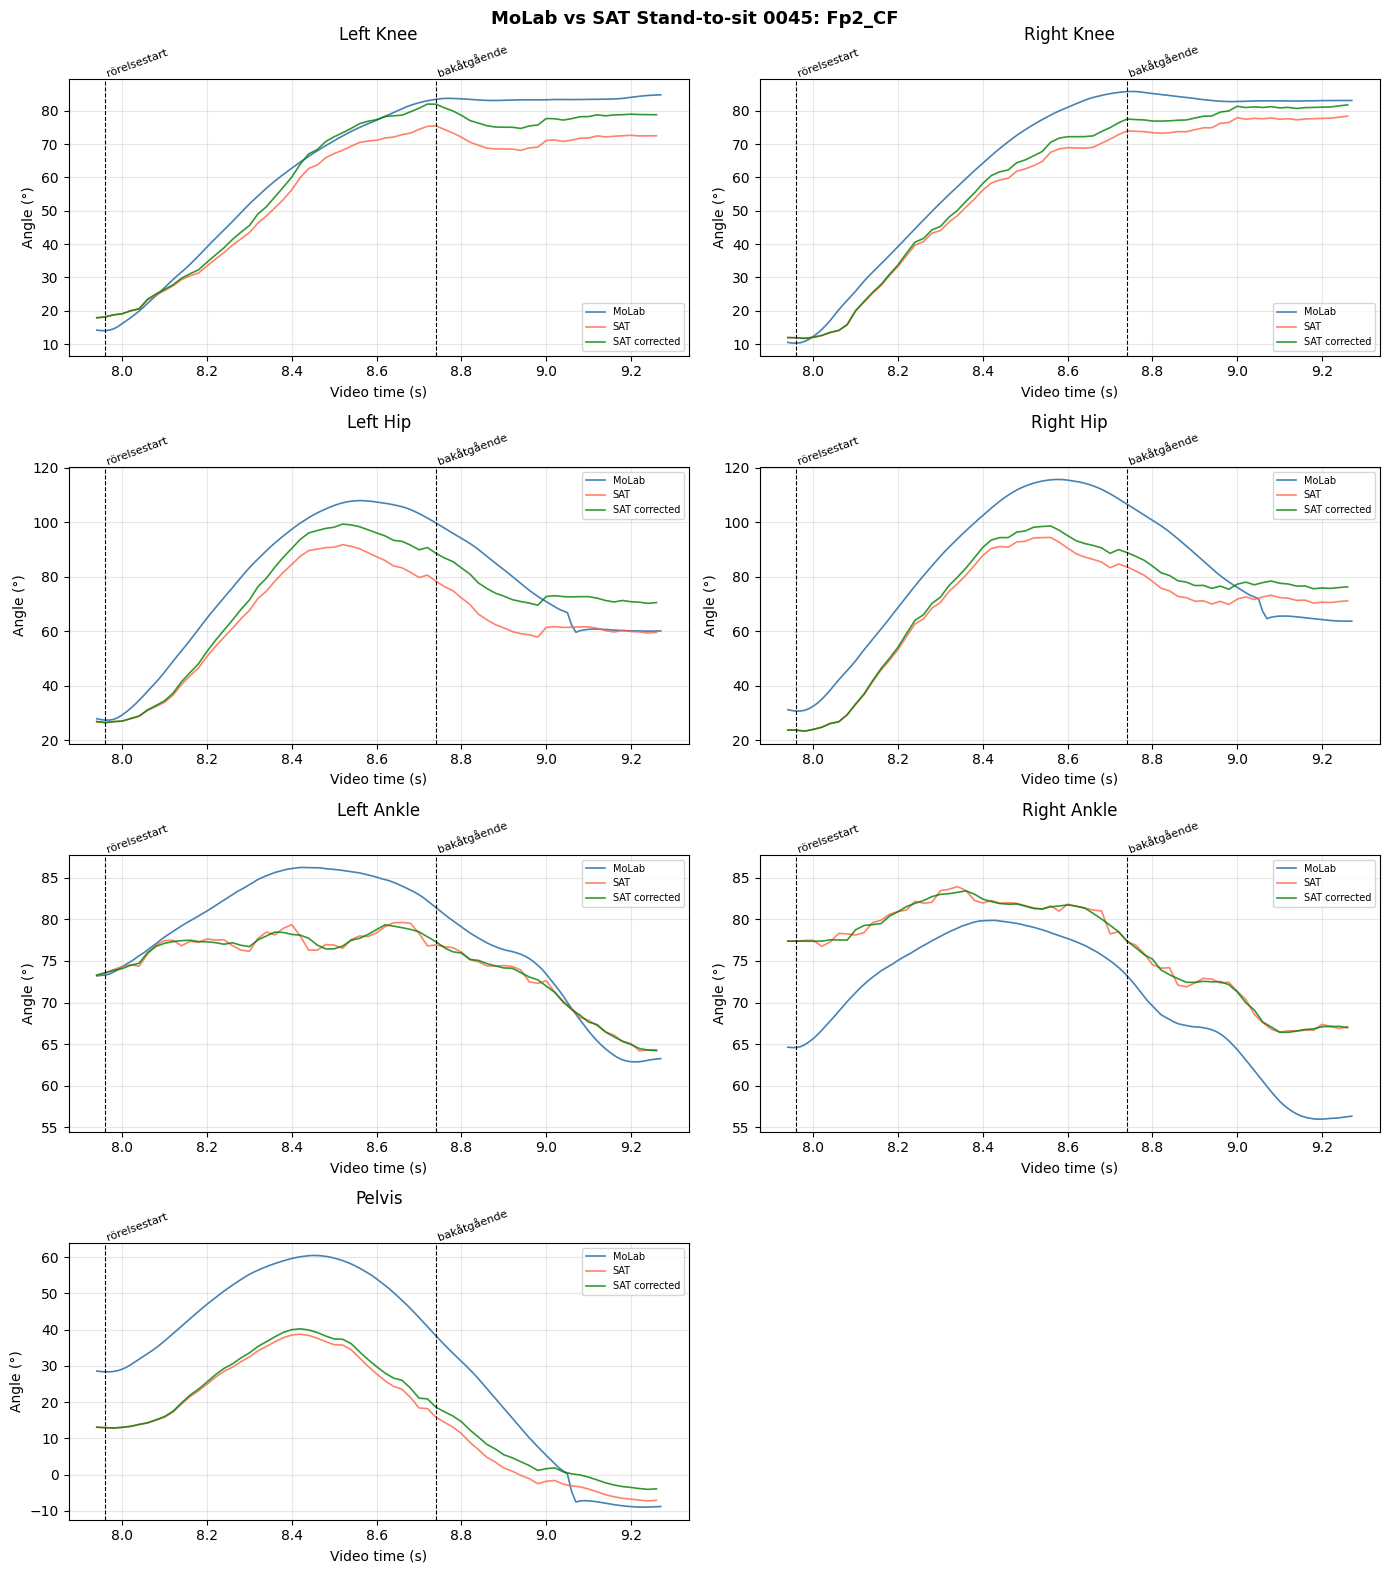

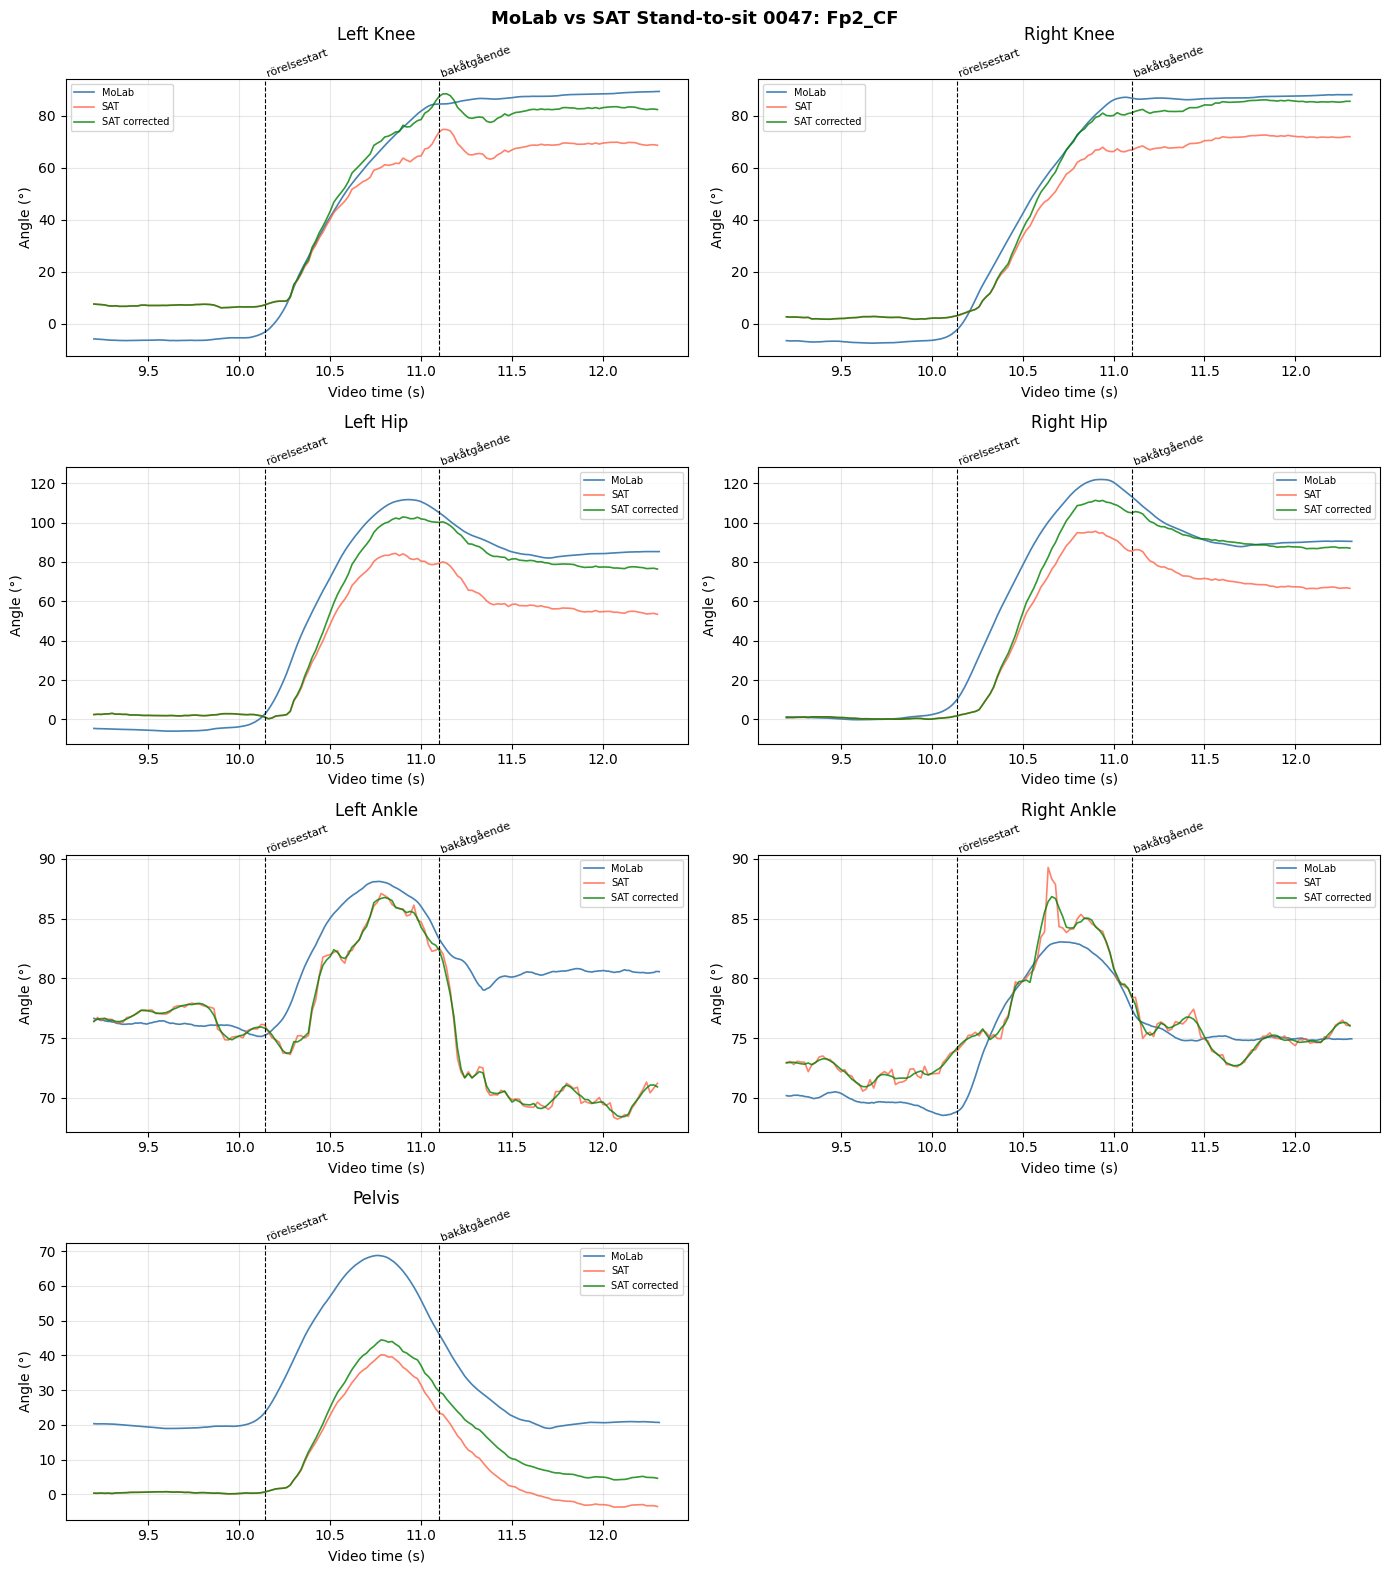

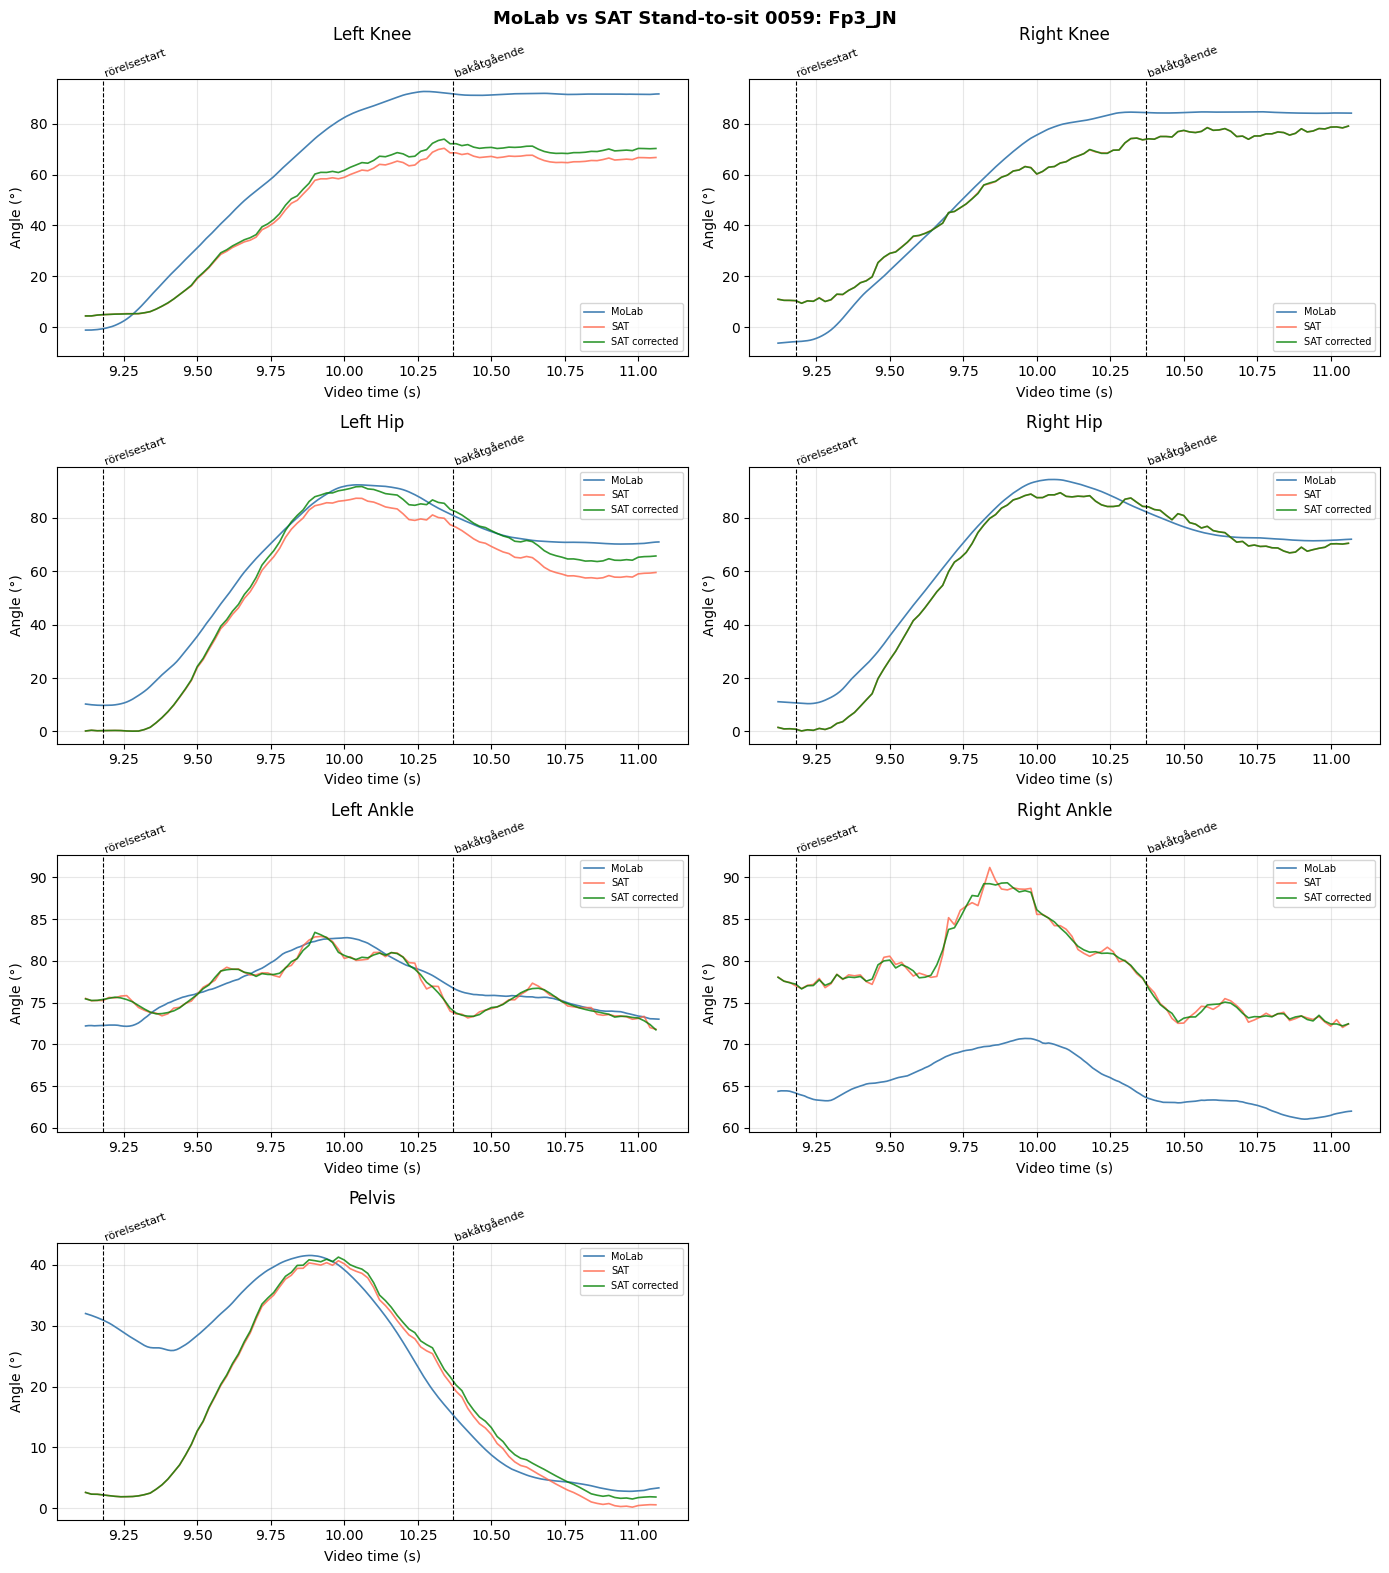

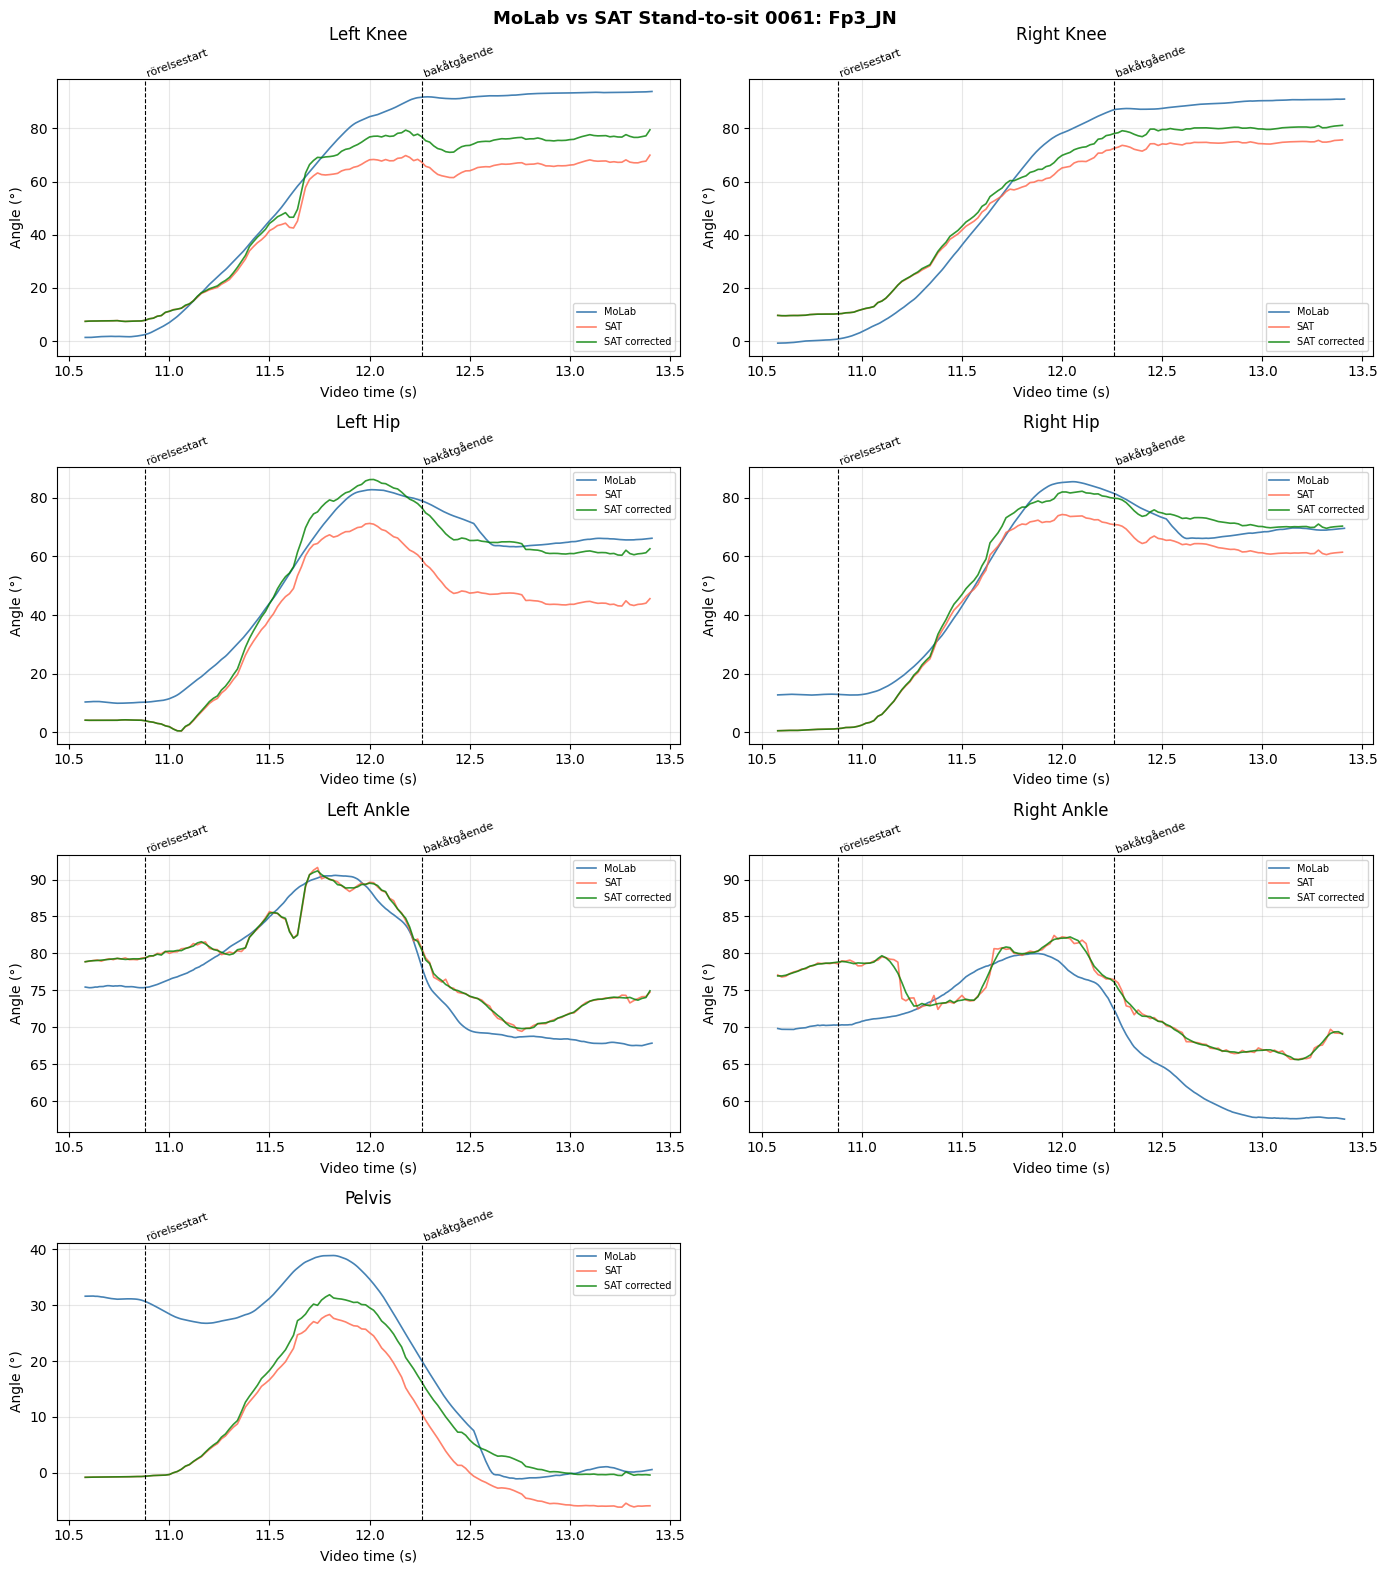

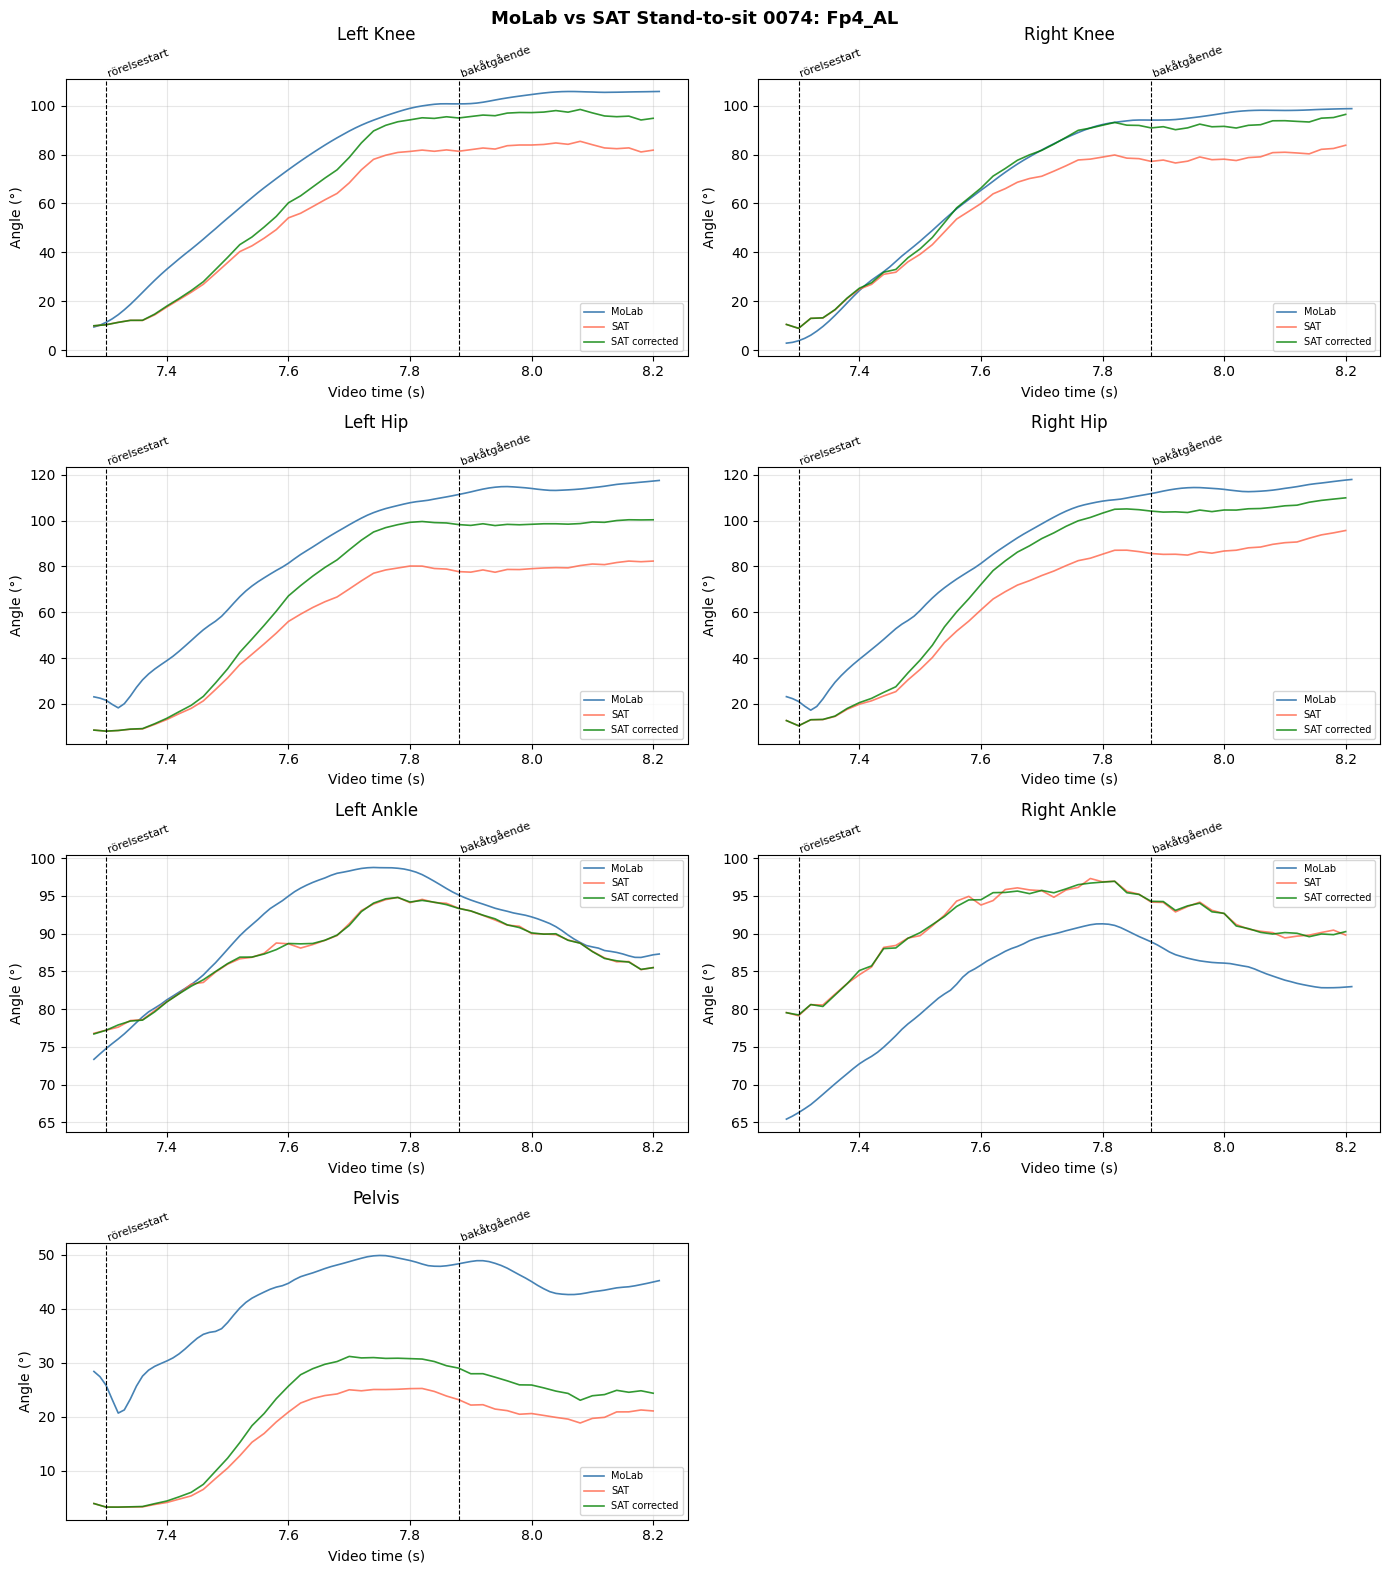

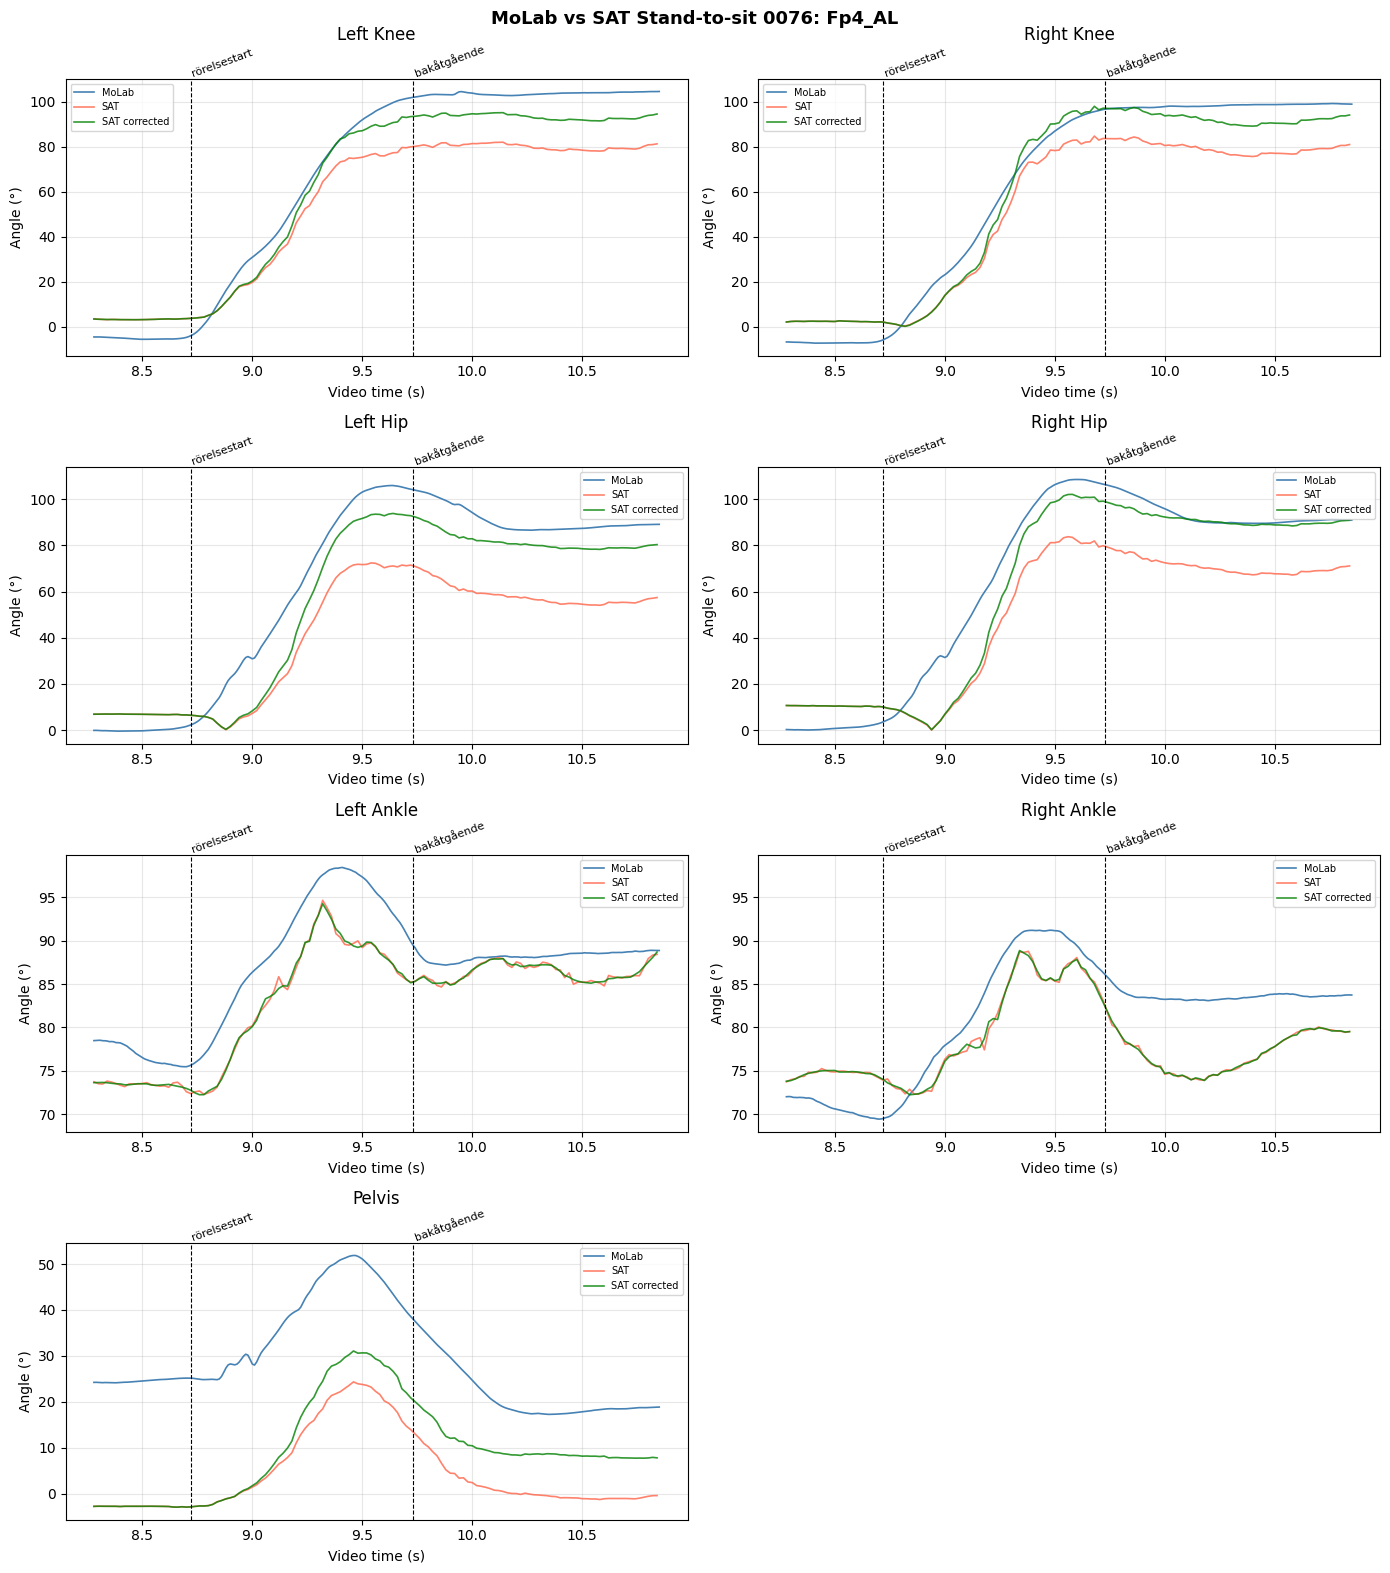

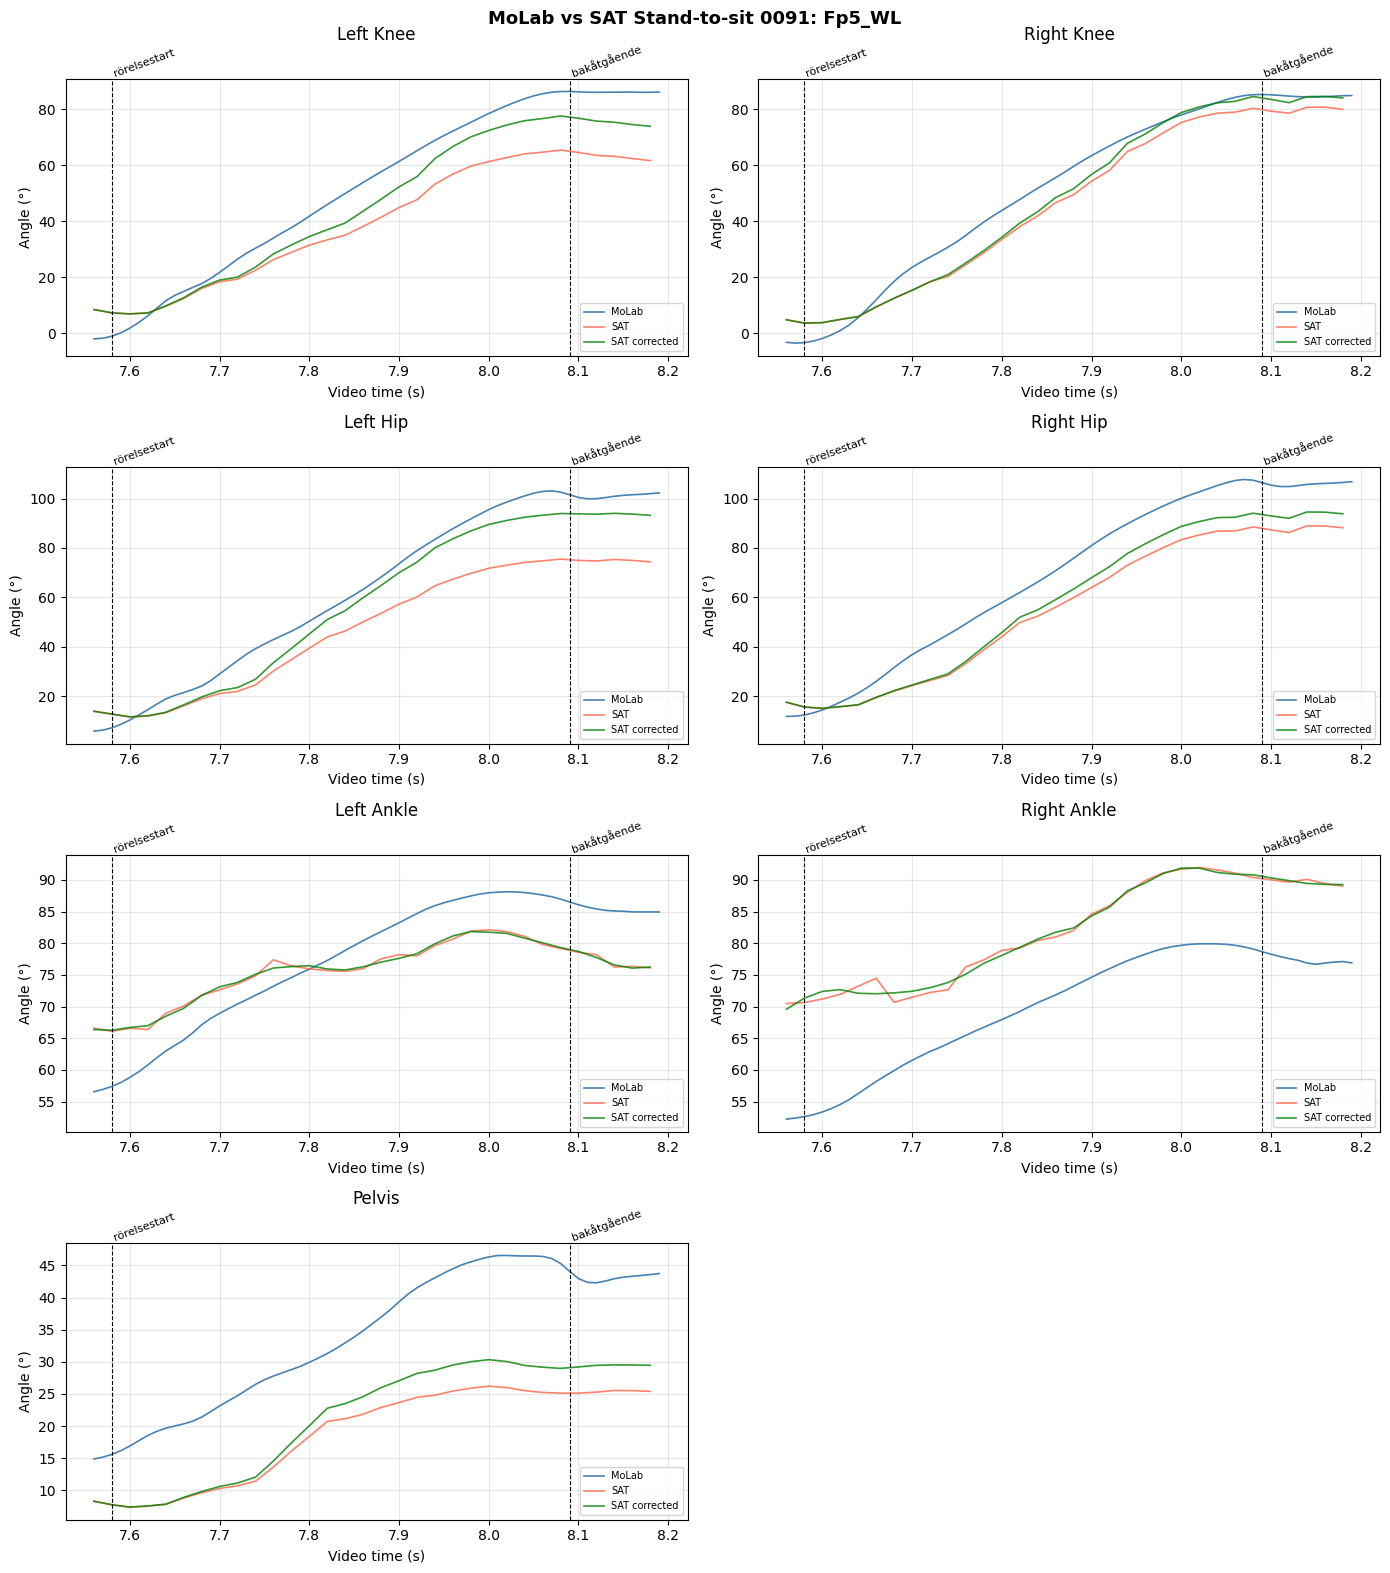

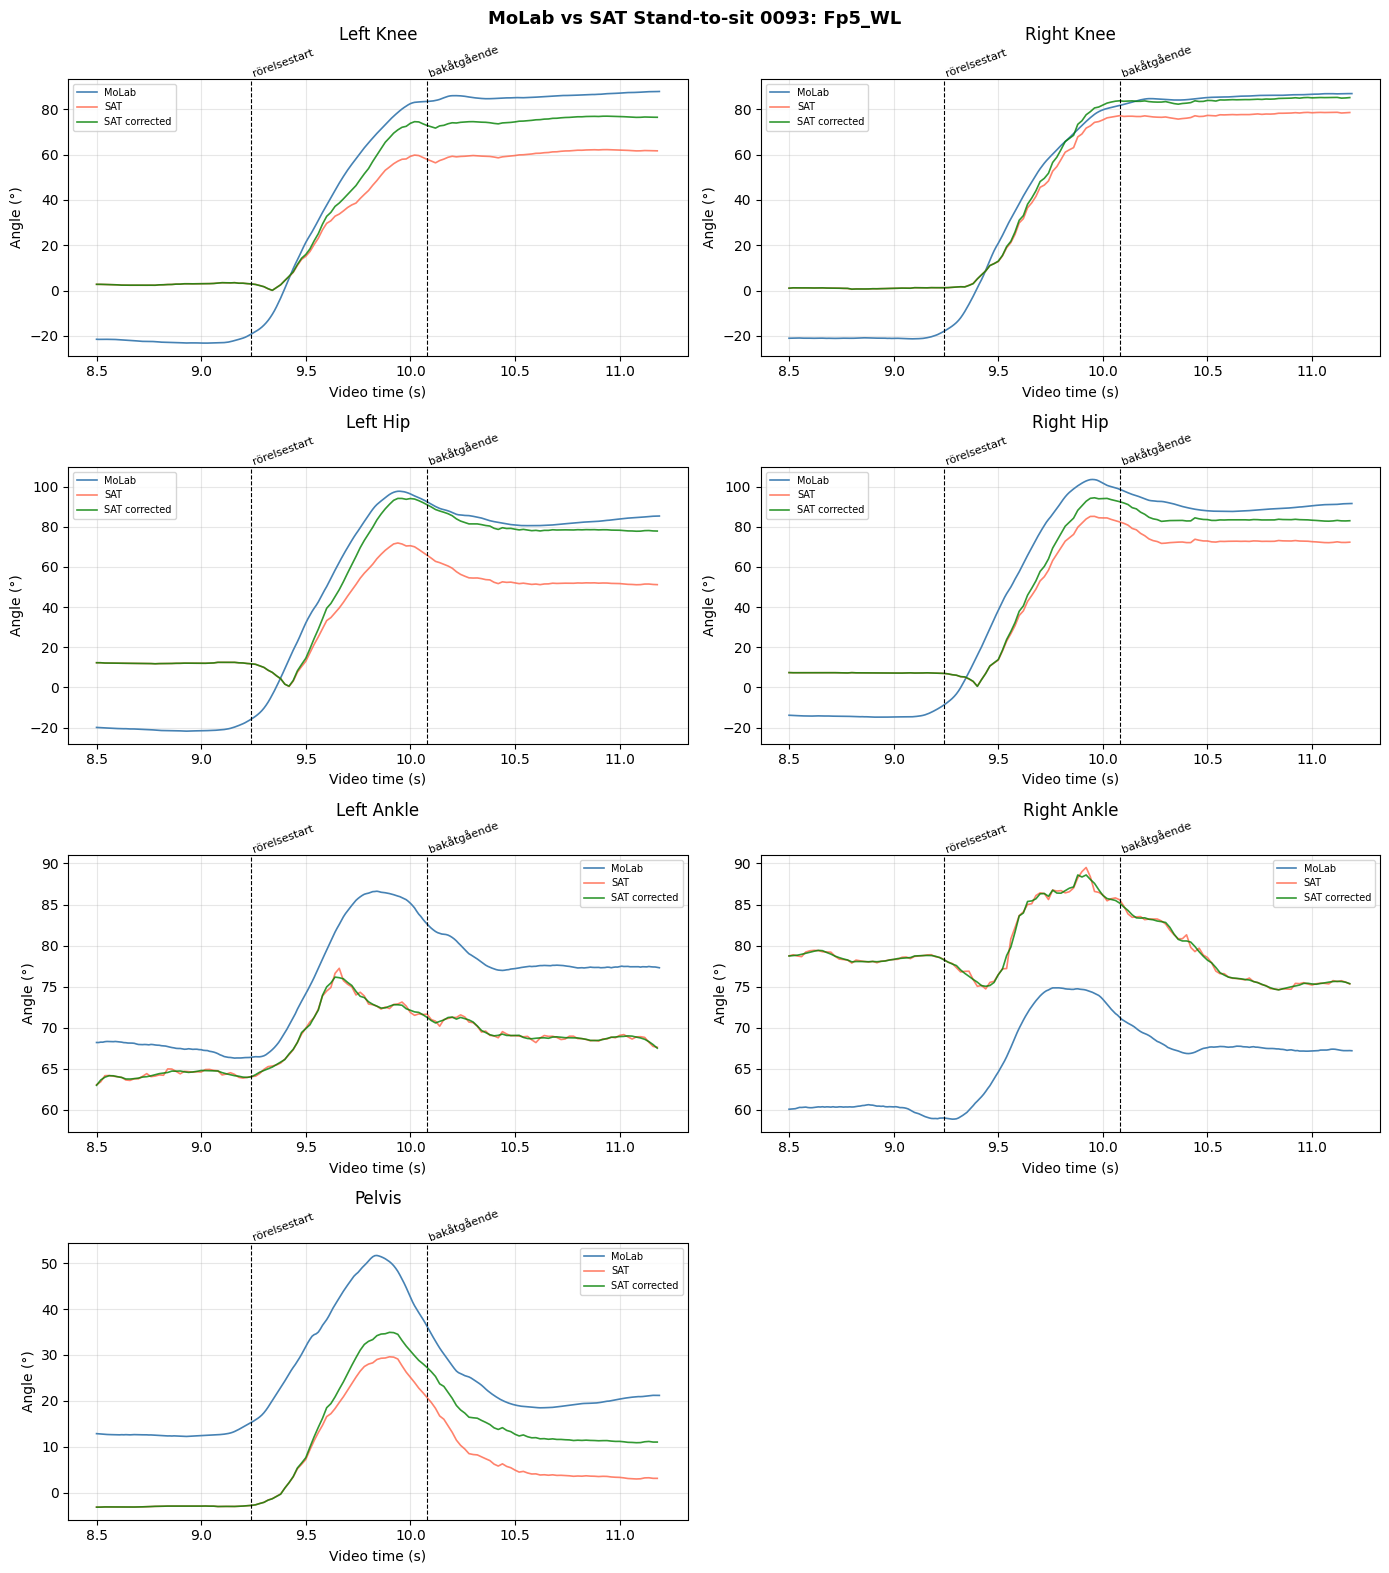

In [6]:
MOLAB_FS = 100
VIDEO_FPS = 50

mapping = [
    ('0028', 'Fp1_SB', '2c'),
    ('0030', 'Fp1_SB', '2e'),
    ('0045', 'Fp2_CF', '2c'),
    ('0047', 'Fp2_CF', '2e'),
    ('0059', 'Fp3_JN', '2c'),
    ('0061', 'Fp3_JN', '2e'),
    ('0074', 'Fp4_AL', '2c'),
    ('0076', 'Fp4_AL', '2e'),
    ('0091', 'Fp5_WL', '2c'),
    ('0093', 'Fp5_WL', '2e'),
]

beep_times = {
    '0028': 9.14,
    '0030': 5.38,
    '0045': 5.88,
    '0047': 6.12,
    '0059': 5.70,
    '0061': 6.10,
    '0074': 5.42,
    '0076': 5.54,
    '0091': 5.52,
    '0093': 5.00,
}

corrections = {
    '0028': 0.52,
}

MOLAB_FULL_DIR = '../data/processed/molab'
ANGLE_PLOTS_DIR = '../data/processed/angle_plots_corrected'
VIDEO_ASPECT = 1920 / 1080

PLOT_JOINTS = [
    ('L_knee_X',  'Left Knee'),
    ('R_knee_X',  'Right Knee'),
    ('L_hip_X',   'Left Hip'),
    ('R_hip_X',   'Right Hip'),
    ('L_ankle_X', 'Left Ankle'),
    ('R_ankle_X', 'Right Ankle'),
    ('pelvis_X',  'Pelvis'),
]

offsets = {}
for vid, fp, mid in mapping:
    full = pd.read_csv(f'{MOLAB_FULL_DIR}/{vid}_molab.csv')
    pre  = full[full['molab_frame'] < 41]
    offsets[vid] = {j: pre[f'JointAngle/{j}'].mean() for j, _ in PLOT_JOINTS}


def joint_angle_2d(ax, ay, bx, by, cx, cy):
    v1x, v1y = ax - bx, ay - by
    v2x, v2y = cx - bx, cy - by
    dot  = v1x * v2x + v1y * v2y
    norm = np.sqrt(v1x**2 + v1y**2) * np.sqrt(v2x**2 + v2y**2) + 1e-8
    return 180 - np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))


def segment_angle_2d(ax, ay, bx, by, cx, cy, dx, dy):
    v1x, v1y = bx - ax, by - ay
    v2x, v2y = dx - cx, dy - cy
    dot  = v1x * v2x + v1y * v2y
    norm = np.sqrt(v1x**2 + v1y**2) * np.sqrt(v2x**2 + v2y**2) + 1e-8
    return 180 - np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))


def trunk_angle_2d(kp):
    mid_hip_x = (kp['left_hip_x'].values + kp['right_hip_x'].values) / 2
    mid_hip_y = (kp['left_hip_y'].values + kp['right_hip_y'].values) / 2
    mid_sh_x  = (kp['left_shoulder_x'].values + kp['right_shoulder_x'].values) / 2
    mid_sh_y  = (kp['left_shoulder_y'].values + kp['right_shoulder_y'].values) / 2
    dx = mid_sh_x - mid_hip_x
    dy = mid_sh_y - mid_hip_y
    return -np.degrees(np.arctan2(dx, -dy))


def compute_kp_angles(kp):
    kp = kp.copy()
    x_cols = [c for c in kp.columns if c.endswith('_x')]
    kp[x_cols] *= VIDEO_ASPECT

    angles = {}
    for side, s in [('L', 'left'), ('R', 'right')]:
        angles[f'{side}_knee_X'] = joint_angle_2d(
            kp[f'{s}_hip_x'].values,    kp[f'{s}_hip_y'].values,
            kp[f'{s}_knee_x'].values,   kp[f'{s}_knee_y'].values,
            kp[f'{s}_ankle_x'].values,  kp[f'{s}_ankle_y'].values,
        )
        angles[f'{side}_hip_X'] = joint_angle_2d(
            kp[f'{s}_shoulder_x'].values, kp[f'{s}_shoulder_y'].values,
            kp[f'{s}_hip_x'].values,      kp[f'{s}_hip_y'].values,
            kp[f'{s}_knee_x'].values,     kp[f'{s}_knee_y'].values,
        )
        angles[f'{side}_ankle_X'] = segment_angle_2d(
            kp[f'{s}_heel_x'].values,       kp[f'{s}_heel_y'].values,
            kp[f'{s}_foot_index_x'].values, kp[f'{s}_foot_index_y'].values,
            kp[f'{s}_ankle_x'].values,      kp[f'{s}_ankle_y'].values,
            kp[f'{s}_knee_x'].values,       kp[f'{s}_knee_y'].values,
        )
    angles['pelvis_X'] = trunk_angle_2d(kp)
    return angles


def plot_molab_angles(molab_dir, kp_dir, kp_cor_dir, kp_pattern, title, out_dir, label, phase_dict, phase_indices):
    os.makedirs(out_dir, exist_ok=True)
    for vid, fp, mid in mapping:
        molab  = pd.read_csv(f'{molab_dir}/{vid}_molab.csv')
        offset = beep_times[vid] - 4 + corrections.get(vid, 0)
        t    = molab['molab_time'].values + offset
        mask = molab['molab_frame'].values >= 41

        kp_files  = glob.glob(f'{kp_dir}/{kp_pattern.format(vid=vid)}')
        kp_angles = None
        kp_time   = None
        if kp_files:
            kp        = pd.read_csv(kp_files[0])
            kp_time   = kp['frame'].values / VIDEO_FPS
            kp_angles = compute_kp_angles(kp)

        kp_cor_files  = glob.glob(f'{kp_cor_dir}/{kp_pattern.format(vid=vid)}')
        kp_cor_angles = None
        kp_cor_time   = None
        if kp_cor_files:
            kp_cor        = pd.read_csv(kp_cor_files[0])
            kp_cor_time   = kp_cor['frame'].values / VIDEO_FPS
            kp_cor_angles = compute_kp_angles(kp_cor)

        vid3 = vid[1:]
        phases = [(phase_dict[vid3][idx], lbl) for idx, lbl in phase_indices if vid3 in phase_dict]

        fig, axes = plt.subplots(4, 2, figsize=(14, 16))
        fig.suptitle(f'{title} {vid}: {fp}', fontsize=13, fontweight='bold')

        for row in range(3):
            axes[row, 1].sharey(axes[row, 0])

        for i, (joint, jlabel) in enumerate(PLOT_JOINTS):
            ax  = axes.flat[i]
            raw = molab[f'JointAngle/{joint}'].values.copy()
            raw[mask] += offsets[vid][joint]
            ax.plot(t, raw, linewidth=1.2, color='steelblue', label='MoLab')

            if kp_angles is not None and joint in kp_angles:
                ax.plot(kp_time, kp_angles[joint], linewidth=1.2,
                        color='tomato', alpha=0.8, label='SAT')

            if kp_cor_angles is not None and joint in kp_cor_angles:
                ax.plot(kp_cor_time, np.asarray(kp_cor_angles[joint]), linewidth=1.2,
                        color='green', alpha=0.8, label='SAT corrected')

            for phase_t, phase_lbl in phases:
                ax.axvline(phase_t, color='black', linestyle='--', linewidth=0.8)
                ax.text(phase_t, 1.0, phase_lbl, transform=ax.get_xaxis_transform(),
                        ha='left', va='bottom', fontsize=8, rotation=20,
                        color='black', clip_on=False)

            ax.set_title(jlabel, pad=28)
            ax.set_xlabel('Video time (s)')
            ax.set_ylabel('Angle (°)')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=7)

        axes.flat[-1].set_visible(False)
        plt.tight_layout()
        plt.savefig(f'{out_dir}/{vid}_{fp}_{label}.png', dpi=150, bbox_inches='tight')
        plt.show()


plot_molab_angles(
    '../data/processed/molab_cropped',
    '../data/processed/keypoints_combined',
    '../data/processed/keypoints_corrected',
    'DJI_*_{vid}_D.csv',
    'MoLab vs SAT Sit-to-stand',
    f'{ANGLE_PLOTS_DIR}/sit_to_stand',
    'sit_to_stand',
    phase_dict=UP_TIME_DICT,
    phase_indices=[(1, 'rörelsestart'), (4, 'uppresningsfas')],
)
plot_molab_angles(
    '../data/processed/molab_cropped_down',
    '../data/processed/keypoints_combined_down',
    '../data/processed/keypoints_corrected_down',
    'DJI_*_{vid}_D.csv',
    'MoLab vs SAT Stand-to-sit',
    f'{ANGLE_PLOTS_DIR}/stand_to_sit',
    'stand_to_sit',
    phase_dict=DOWN_TIME_DICT,
    phase_indices=[(1, 'rörelsestart'), (3, 'bakåtgående')],
)

## Save videos

* Blue = corrected
* Green = original

In [7]:
import imageio
import re

VIDEO_DIR       = Path('../data/Utvalda filminspelningar för IRAF analys/Dec 2025 sit-stå och stå-sitt')

OUT_UP_DIR = Path('../data/processed/keypoints_corrected')
OUT_DOWN_DIR = Path('../data/processed/keypoints_corrected_down')

OUT_UP_ORIG_DIR = Path('../data/processed/keypoints_combined')
OUT_DOWN_ORIG_DIR = Path('../data/processed/keypoints_combined_down')

OUT_UP_VIDEOS = Path('../data/processed/keypoints_corrected_videos')
OUT_DOWN_VIDEOS = Path('../data/processed/keypoints_corrected_down_videos')

time_dict = {
    '028': (9.90,  11.77), '030': (5.80,  7.63),
    '045': (6.54,   7.98), '047': (7.03,  8.91),
    '059': (6.65,   9.11), '061': (6.00,  9.00),
    '074': (6.07,   7.27), '076': (5.00,  8.00),
    '091': (6.39,   7.61), '093': (5.86,  7.67),
}

stand_to_sit_time_dict = {
    '028': (11.87, 12.87), '030': (8.07,  11.56),
    '045': (7.94,   9.26), '047': (9.20,  12.30),
    '059': (9.11,  11.06), '061': (10.57, 13.41),
    '074': (7.27,   8.20), '076': (8.27,  10.84),
    '091': (7.56,   8.18), '093': (8.50,  11.19),
}

JOINTS = [
    'nose',
    'left_ear',
    'left_shoulder', 'right_shoulder',
    'left_elbow',    'right_elbow',
    'left_wrist',    'right_wrist',
    'left_hip',      'right_hip',
    'left_knee',     'right_knee',
    'left_ankle',    'right_ankle',
]

MEDIAPIPE_EXTRA_JOINTS = [
    'left_heel',       'right_heel',
    'left_foot_index', 'right_foot_index',
]

ALL_JOINTS = JOINTS + MEDIAPIPE_EXTRA_JOINTS

CORRECTION_TOL = 1e-6


def draw_keypoints_on_image(image, orig_row, corr_row):
    height, width, _ = image.shape
    dpi = 100
    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.margins(0)
    ax.axis('off')
    ax.imshow(image)

    for joint in ALL_JOINTS:
        ox = orig_row.get(f'{joint}_x')
        oy = orig_row.get(f'{joint}_y')
        cx = corr_row.get(f'{joint}_x')
        cy = corr_row.get(f'{joint}_y')

        if pd.isna(ox) or pd.isna(oy):
            continue

        corrected = (not pd.isna(cx) and not pd.isna(cy) and
                     (abs(cx - ox) > CORRECTION_TOL or abs(cy - oy) > CORRECTION_TOL))

        ax.scatter([ox * width], [oy * height], c='#50c850', s=50)
        if corrected:
            ax.scatter([cx * width], [cy * height], c='#5050ff', s=50)

    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.tostring_argb(), dtype=np.uint8)
    buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    img = buf[:, :, 1:4]
    plt.close(fig)
    return img


for corr_dir, orig_dir, out_video, td, label in [
    (OUT_UP_DIR,   OUT_UP_ORIG_DIR,   OUT_UP_VIDEOS,   time_dict,              'sit-to-stand'),
    (OUT_DOWN_DIR, OUT_DOWN_ORIG_DIR, OUT_DOWN_VIDEOS, stand_to_sit_time_dict, 'stand-to-sit'),
]:
    out_video.mkdir(parents=True, exist_ok=True)
    print(f'\n=== {label} ===')
    for csv_path in sorted(corr_dir.glob('*.csv')):
        match = re.search(r'_0(\d{3})_D', csv_path.stem)
        if not match:
            continue
        vid_id    = match.group(1)
        vid_files = list(VIDEO_DIR.glob(f'*_0{vid_id}_D.MP4'))

        if not vid_files:
            print(f'Video not found: {vid_id}')
            continue

        orig_path = orig_dir / csv_path.name
        if not orig_path.exists():
            print(f'Original not found: {orig_path.name}')
            continue

        corr_df = pd.read_csv(csv_path)
        orig_df = pd.read_csv(orig_path)
        out_path    = out_video / f'{csv_path.stem}.mp4'
        start_frame = int(td[vid_id][0] * VIDEO_FPS)
        reader      = imageio.get_reader(str(vid_files[0]))

        with imageio.get_writer(str(out_path), fps=VIDEO_FPS) as writer:
            for i, (corr_row, orig_row) in enumerate(zip(corr_df.itertuples(), orig_df.itertuples())):
                frame = reader.get_data(start_frame + i)
                writer.append_data(draw_keypoints_on_image(frame, orig_row._asdict(), corr_row._asdict()))

        reader.close()
        print(f'{vid_id}: saved -> {out_path.name}')


=== sit-to-stand ===
Video not found: 028
Video not found: 030
Video not found: 045
Video not found: 047
Video not found: 059
Video not found: 061
Video not found: 074
Video not found: 076
Video not found: 091
Video not found: 093

=== stand-to-sit ===
Video not found: 028
Video not found: 030
Video not found: 045
Video not found: 047
Video not found: 059
Video not found: 061
Video not found: 074
Video not found: 076
Video not found: 091
Video not found: 093
